# LOAD DATA

In [143]:
import numpy as np, pandas as pd, os, gc, datetime
from pandas.conftest import axis
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar
import re

In [144]:
DATA_DIR = Path("/ieee-fraud-detection")
START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')

In [145]:
train_transaction_path = DATA_DIR / "train_transaction.csv"
test_transaction_path = DATA_DIR / "test_transaction.csv"
train_identity_path = DATA_DIR / "train_identity.csv"
test_identity_path = DATA_DIR / "test_identity.csv"

In [283]:
train_transaction = pd.read_csv(train_transaction_path)

train_identity = pd.read_csv(train_identity_path)

test_transaction = pd.read_csv(test_transaction_path)

test_identity = pd.read_csv(test_identity_path)

In [147]:
# Original train transaction data
train_transaction

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
# Original test transaction data
test_transaction

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.950,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.000,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.950,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.950,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506686,4170235,34214279,94.679,C,13832,375.0,185.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506687,4170236,34214287,12.173,C,3154,408.0,185.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506688,4170237,34214326,49.000,W,16661,490.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506689,4170238,34214337,202.000,W,16621,516.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
dates_range = pd.date_range("2017-10-01", "2019-01-01")
us_holidays = calendar().holidays(dates_range.min(), dates_range.max())

TIME_COLS = [
    "DT", "DT_M", "DT_W", "DT_D",
    "DT_hour", "DT_day_week", "DT_day_month", "DT_week_month",
    "is_december", "is_holiday",
    "DT_M_total", "DT_W_total", "DT_D_total"
]

def add_time_features(df):
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.drop(columns=[c for c in TIME_COLS if c in df.columns], errors="ignore")

    dt = START_DATE + pd.to_timedelta(df["TransactionDT"], unit="s")
    iso_week = dt.dt.isocalendar().week.astype("int16")

    feats = pd.DataFrame({
        "DT": dt,
        "DT_M": (((dt.dt.year - 2017) * 12 + dt.dt.month)).astype("int8"),
        "DT_W": (((dt.dt.year - 2017) * 52 + iso_week)).astype("int16"),
        "DT_D": (((dt.dt.year - 2017) * 365 + dt.dt.dayofyear)).astype("int16"),
        "DT_hour": dt.dt.hour.astype("int8"),
        "DT_day_week": dt.dt.dayofweek.astype("int8"),
        "DT_day_month": dt.dt.day.astype("int8"),
        "DT_week_month": (((dt.dt.day - 1) // 7) + 1).astype("int8"),
        "is_december": (dt.dt.month == 12).astype("int8"),
        "is_holiday": dt.dt.normalize().isin(us_holidays).astype("int8"),
    }, index=df.index)

    return pd.concat([df, feats], axis=1)

train_df = add_time_features(train_transaction)
test_df = add_time_features(test_transaction)

for col in ["DT_M", "DT_W", "DT_D"]:
    vals = np.concatenate([train_df[col].to_numpy(), test_df[col].to_numpy()])
    fq = pd.Series(vals).value_counts().to_dict()
    train_df[f"{col}_total"] = train_df[col].map(fq)
    test_df[f"{col}_total"] = test_df[col].map(fq)

In [150]:
train_df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,DT_D,DT_hour,DT_day_week,DT_day_month,DT_week_month,is_december,is_holiday,DT_M_total,DT_W_total,DT_D_total
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,335,0,4,1,1,1,0,137321,12093,5122
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,335,0,4,1,1,1,0,137321,12093,5122
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,335,0,4,1,1,1,0,137321,12093,5122
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,335,0,4,1,1,1,0,137321,12093,5122
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,335,0,4,1,1,1,0,137321,12093,5122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,516,23,3,31,5,0,0,89326,10288,2754
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,516,23,3,31,5,0,0,89326,10288,2754
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,516,23,3,31,5,0,0,89326,10288,2754
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,516,23,3,31,5,0,0,89326,10288,2754


In [151]:
test_df

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,DT_D,DT_hour,DT_day_week,DT_day_month,DT_week_month,is_december,is_holiday,DT_M_total,DT_W_total,DT_D_total
0,3663549,18403224,31.950,W,10409,111.0,150.0,visa,226.0,debit,...,547,0,6,1,1,0,0,78430,2243,2243
1,3663550,18403263,49.000,W,4272,111.0,150.0,visa,226.0,debit,...,547,0,6,1,1,0,0,78430,2243,2243
2,3663551,18403310,171.000,W,4476,574.0,150.0,visa,226.0,debit,...,547,0,6,1,1,0,0,78430,2243,2243
3,3663552,18403310,284.950,W,10989,360.0,150.0,visa,166.0,debit,...,547,0,6,1,1,0,0,78430,2243,2243
4,3663553,18403317,67.950,W,18018,452.0,150.0,mastercard,117.0,debit,...,547,0,6,1,1,0,0,78430,2243,2243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506686,4170235,34214279,94.679,C,13832,375.0,185.0,mastercard,224.0,debit,...,729,23,6,30,5,1,0,116398,28119,2514
506687,4170236,34214287,12.173,C,3154,408.0,185.0,mastercard,224.0,debit,...,729,23,6,30,5,1,0,116398,28119,2514
506688,4170237,34214326,49.000,W,16661,490.0,150.0,visa,226.0,debit,...,729,23,6,30,5,1,0,116398,28119,2514
506689,4170238,34214337,202.000,W,16621,516.0,150.0,mastercard,224.0,debit,...,729,23,6,30,5,1,0,116398,28119,2514


# Process D columns

# NORMALIZE D COLUMNS
The D Columns are "time deltas" from some point in the past. We will transform the D Columns into their point in the past. This will stop the D columns from increasing with time. The formula is D15n = Transaction_Day - D15 and Transaction_Day = TransactionDT/(24*60*60). Afterward we multiply this number by negative one.

In [152]:
d_cols = train_df.columns[train_df.columns.str.match(r"^D\d+$")]
print(train_df[d_cols].dtypes)

D1     float64
D2     float64
D3     float64
D4     float64
D5     float64
D6     float64
D7     float64
D8     float64
D9     float64
D10    float64
D11    float64
D12    float64
D13    float64
D14    float64
D15    float64
dtype: object


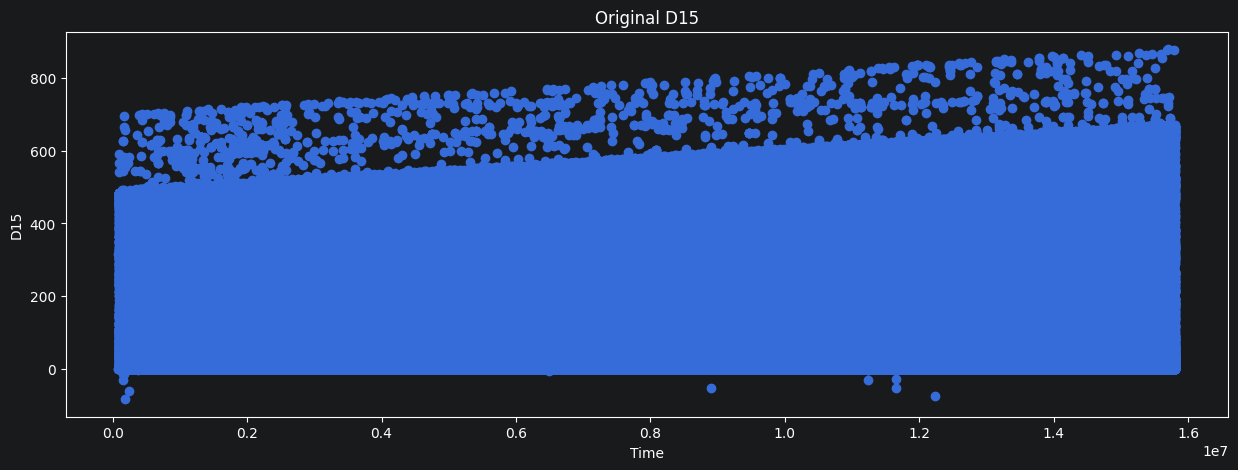

In [153]:
# PLOT ORIGINAL D
plt.figure(figsize=(15,5))
plt.scatter(train_transaction.TransactionDT,train_transaction.D15)
plt.title('Original D15')
plt.xlabel('Time')
plt.ylabel('D15')
plt.show()

In [154]:
print(train_df[d_cols])

           D1     D2    D3    D4   D5  D6  D7  D8  D9   D10    D11  D12  D13  \
0        14.0    NaN  13.0   NaN  NaN NaN NaN NaN NaN  13.0   13.0  NaN  NaN   
1         0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0    NaN  NaN  NaN   
2         0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0  315.0  NaN  NaN   
3       112.0  112.0   0.0  94.0  0.0 NaN NaN NaN NaN  84.0    NaN  NaN  NaN   
4         0.0    NaN   NaN   NaN  NaN NaN NaN NaN NaN   NaN    NaN  NaN  NaN   
...       ...    ...   ...   ...  ...  ..  ..  ..  ..   ...    ...  ...  ...   
590535   29.0   29.0  30.0   NaN  NaN NaN NaN NaN NaN  56.0   56.0  NaN  NaN   
590536    0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0    0.0  NaN  NaN   
590537    0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0    0.0  NaN  NaN   
590538   22.0   22.0   0.0  22.0  0.0 NaN NaN NaN NaN  22.0   22.0  NaN  NaN   
590539    0.0    NaN   0.0   1.0  0.0 NaN NaN NaN NaN   1.0    0.0  NaN  NaN   

        D14    D15  
0       NaN    0.0

In [155]:
print(test_df[d_cols])

           D1     D2    D3     D4    D5    D6    D7         D8        D9  \
0       419.0  419.0  27.0  398.0  27.0   NaN   NaN        NaN       NaN   
1       149.0  149.0   7.0  634.0   7.0   NaN   NaN        NaN       NaN   
2       137.0  137.0  10.0   97.0  10.0   NaN   NaN        NaN       NaN   
3        42.0   42.0  41.0  242.0  41.0   NaN   NaN        NaN       NaN   
4        22.0   22.0   0.0   22.0   0.0   NaN   NaN        NaN       NaN   
...       ...    ...   ...    ...   ...   ...   ...        ...       ...   
506686    0.0    NaN   NaN    0.0   NaN   0.0   NaN        NaN       NaN   
506687   16.0   16.0  16.0   16.0  16.0  16.0  16.0        NaN       NaN   
506688    0.0    NaN   NaN    0.0   NaN   NaN   NaN        NaN       NaN   
506689    0.0    NaN   NaN    0.0   NaN   NaN   NaN        NaN       NaN   
506690    0.0    NaN   NaN    0.0   NaN   0.0   NaN  29.958332  0.958333   

          D10    D11   D12  D13  D14    D15  
0       418.0  203.0   NaN  NaN  NaN  409

# Approach 1

In [156]:
def transform_d_columns(df: pd.DataFrame) -> pd.DataFrame:
    if "TransactionDT" not in df.columns:
        return df
    transaction_day = np.floor(df["TransactionDT"] / np.float32(24*60*60))
    for col in d_cols:
        df[col] = transaction_day - df[col]
    return df

In [157]:
# Transform all D columns
train_df = transform_d_columns(train_df)
test_df = transform_d_columns(test_df)

In [158]:
print(train_df[d_cols])

           D1     D2     D3     D4     D5  D6  D7  D8  D9    D10    D11  D12  \
0       -13.0    NaN  -12.0    NaN    NaN NaN NaN NaN NaN  -12.0  -12.0  NaN   
1         1.0    NaN    NaN    1.0    NaN NaN NaN NaN NaN    1.0    NaN  NaN   
2         1.0    NaN    NaN    1.0    NaN NaN NaN NaN NaN    1.0 -314.0  NaN   
3      -111.0 -111.0    1.0  -93.0    1.0 NaN NaN NaN NaN  -83.0    NaN  NaN   
4         1.0    NaN    NaN    NaN    NaN NaN NaN NaN NaN    NaN    NaN  NaN   
...       ...    ...    ...    ...    ...  ..  ..  ..  ..    ...    ...  ...   
590535  153.0  153.0  152.0    NaN    NaN NaN NaN NaN NaN  126.0  126.0  NaN   
590536  182.0    NaN    NaN  182.0    NaN NaN NaN NaN NaN  182.0  182.0  NaN   
590537  182.0    NaN    NaN  182.0    NaN NaN NaN NaN NaN  182.0  182.0  NaN   
590538  160.0  160.0  182.0  160.0  182.0 NaN NaN NaN NaN  160.0  160.0  NaN   
590539  182.0    NaN  182.0  181.0  182.0 NaN NaN NaN NaN  181.0  182.0  NaN   

        D13  D14    D15  
0       NaN  

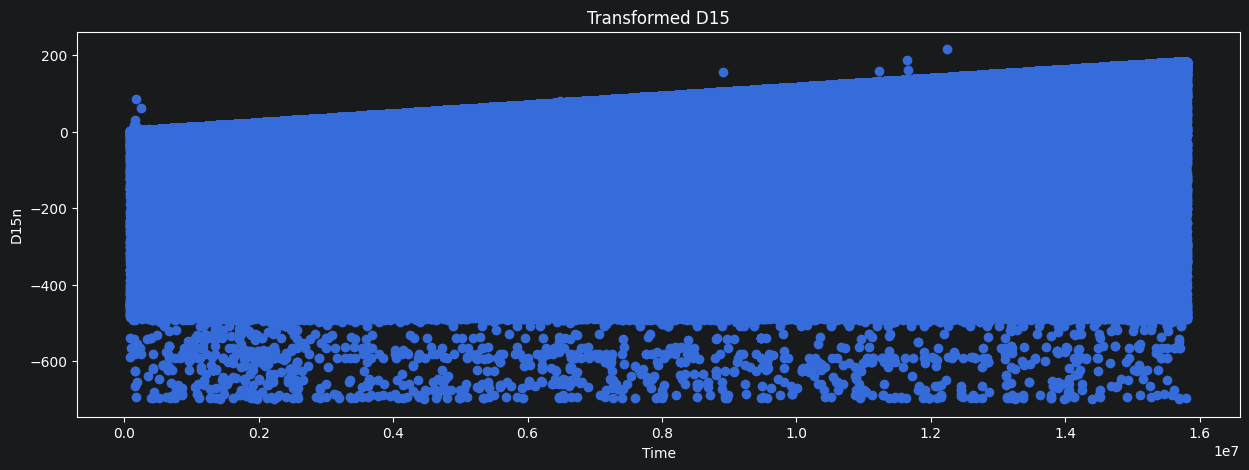

In [159]:
# PLOT TRANSFORMED D
plt.figure(figsize=(15,5))
plt.scatter(train_df.TransactionDT,train_df.D15)
plt.title('Transformed D15')
plt.xlabel('Time')
plt.ylabel('D15n')
plt.show()

In [160]:
print(train_df[d_cols].dtypes)

D1     float64
D2     float64
D3     float64
D4     float64
D5     float64
D6     float64
D7     float64
D8     float64
D9     float64
D10    float64
D11    float64
D12    float64
D13    float64
D14    float64
D15    float64
dtype: object


In [161]:
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

null_pct = df[d_cols].isna().mean().mul(100).sort_values(ascending=False)

null_table = null_pct.reset_index()
null_table.columns = ["column", "null_percent"]
print("Null percentage for each D column: \n", null_table)

Null percentage for each D column: 
    column  null_percent
0      D7     90.972730
1     D12     87.790082
2      D8     86.396301
3      D9     86.396301
4     D14     83.833760
5     D13     83.108753
6      D6     81.957309
7      D5     48.687651
8      D2     46.987918
9      D3     42.472369
10    D11     41.541389
11     D4     22.399385
12    D15      9.221577
13    D10      8.071865
14     D1      0.665311


In [162]:
# fit on train only -> only take medians from data in train and then fillna() in both train and test.
medians = train_df[d_cols].median()

for c in d_cols:
    train_df[c + "_isna"] = train_df[c].isna().astype("int8")
    test_df[c + "_isna"]  = test_df[c].isna().astype("int8")
    df[c + "_isna"] = df[c].isna().astype("int8")
    df[c] = df[c].fillna(df[c].median()) # fit median on train only in real pipeline

train_df[d_cols] = train_df[d_cols].fillna(medians)
test_df[d_cols]  = test_df[d_cols].fillna(medians)

In [163]:
train_df

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,D6_isna,D7_isna,D8_isna,D9_isna,D10_isna,D11_isna,D12_isna,D13_isna,D14_isna,D15_isna
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,1,1,1,1,0,0,1,1,1,0
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,1,1,1,1,0,1,1,1,1,0
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,1,1,1,1,0,0,1,1,1,0
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,1,1,1,1,0,1,1,1,1,0
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,1,1,1,1,0,0,1,1,1,0
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,1,1,1,1,0,0,1,1,1,0
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,1,1,1,1,0,0,1,1,1,0
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,1,1,1,1,0,0,1,1,1,0


In [164]:
def make_corr(Vs,Vtitle=''):
    cols = ['TransactionDT'] + Vs
    plt.figure(figsize=(15,15))
    sns.heatmap(train_transaction[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
    if Vtitle!='': plt.title(Vtitle,fontsize=14)
    else: plt.title(Vs[0]+' - '+Vs[-1],fontsize=14)
    plt.show()

In [165]:
def reduce_group(grps,c='V'):
    use = []
    for g in grps:
        mx = 0; vx = g[0]
        for gg in g:
            n = train_transaction[c+str(gg)].nunique()
            if n>mx:
                mx = n
                vx = gg
        use.append(vx)
    return use

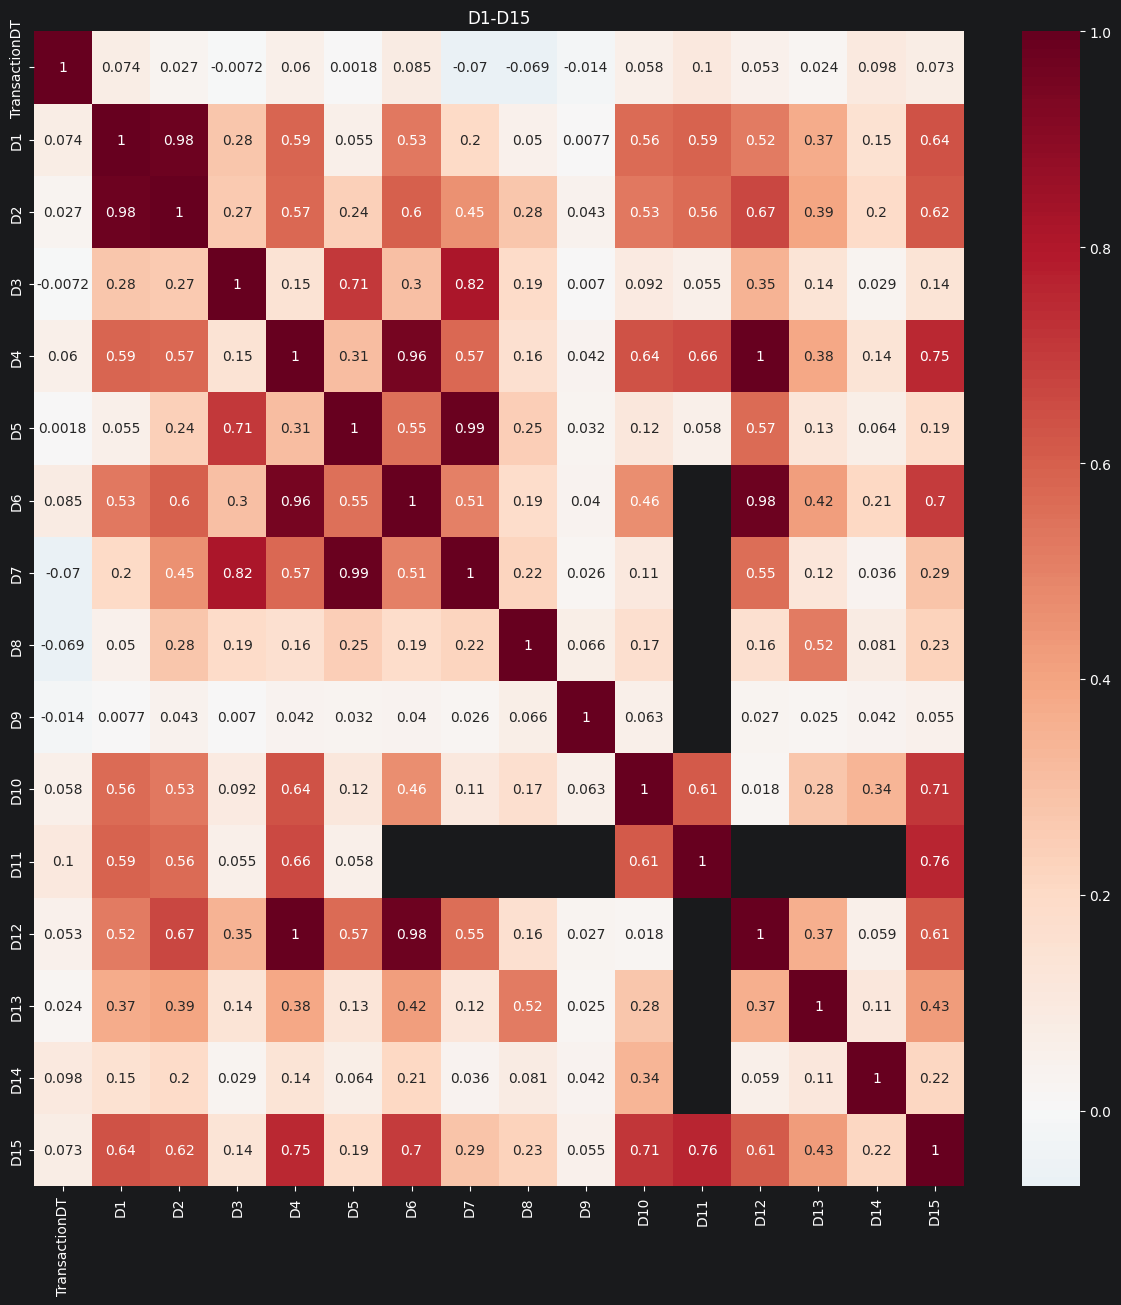

In [166]:
cols = ['TransactionDT'] + ['D'+str(x) for x in range(1,16)]
plt.figure(figsize=(15,15))
sns.heatmap(train_transaction[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('D1-D15')
plt.show()

In [167]:
grps = [
 [3, 4, 5, 6, 7, 11, 12, 15],
 [1, 2],
 [8],
 [9],
 [10],
 [13],
 [14]
]

d_grps = reduce_group(grps, c='D')
print(d_grps)

[15, 1, 8, 9, 10, 13, 14]


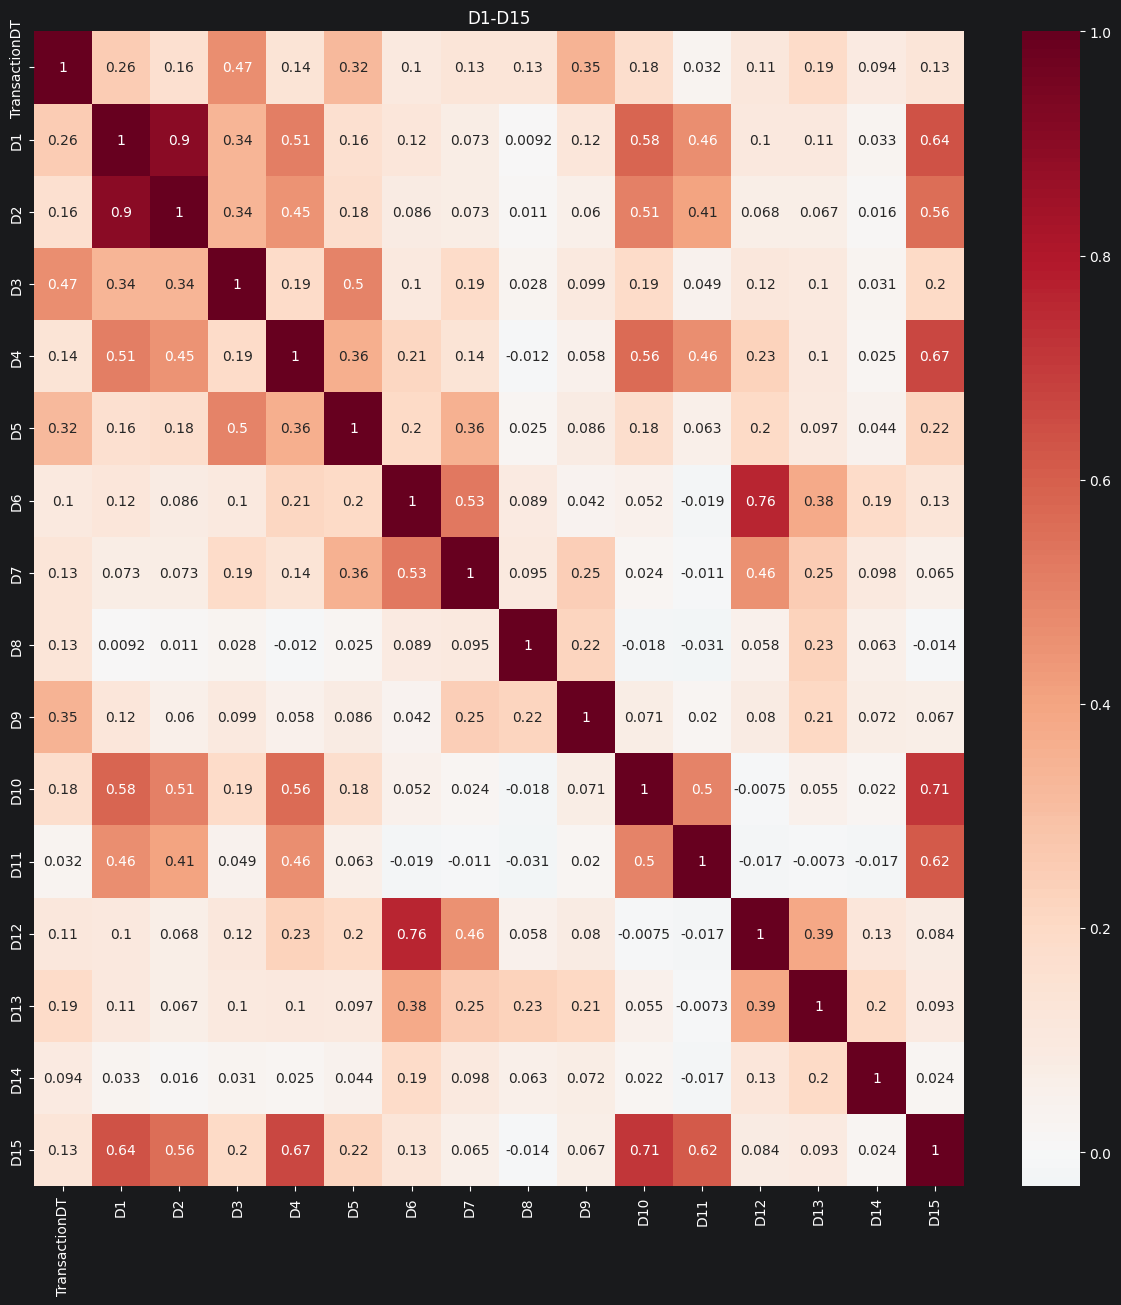

In [168]:
cols = ['TransactionDT'] + ['D'+str(x) for x in range(1,16)]
plt.figure(figsize=(15,15))
sns.heatmap(train_df[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('D1-D15')
plt.show()

# Process C columns

In [169]:
c_cols = train_df.columns[train_df.columns.str.match(r"^C\d+$")]
print(train_df[c_cols].dtypes)

C1     float64
C2     float64
C3     float64
C4     float64
C5     float64
C6     float64
C7     float64
C8     float64
C9     float64
C10    float64
C11    float64
C12    float64
C13    float64
C14    float64
dtype: object


In [170]:
c_profile = pd.DataFrame({
    "nunique": train_df[c_cols].nunique(dropna=True),
    "nunique_incl_nan": train_df[c_cols].nunique(dropna=False),
    "null_pct": train_df[c_cols].isna().mean() * 100,
    "zero_pct": (train_df[c_cols] == 0).mean() * 100,
    "min": train_df[c_cols].min(),
    "p50": train_df[c_cols].median(),
    "p95": train_df[c_cols].quantile(0.95),
    "max": train_df[c_cols].max(),
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(c_profile)

     nunique  nunique_incl_nan  null_pct   zero_pct  min  p50    p95     max
C3        27                27       0.0  99.588682  0.0  0.0    0.0    26.0
C9       205               205       0.0  31.123209  0.0  1.0    9.0   210.0
C5       319               319       0.0  63.066854  0.0  0.0    9.0   349.0
C7      1103              1103       0.0  88.587056  0.0  0.0    1.0  2255.0
C14     1108              1108       0.0   6.087141  0.0  1.0   14.0  1429.0
C12     1199              1199       0.0  82.839266  0.0  0.0    1.0  3188.0
C2      1216              1216       0.0   0.075016  0.0  1.0   27.0  5691.0
C10     1231              1231       0.0  76.784299  0.0  0.0    2.0  3257.0
C8      1253              1253       0.0  75.806381  0.0  0.0    2.0  3331.0
C4      1260              1260       0.0  76.520303  0.0  0.0    1.0  2253.0
C6      1328              1328       0.0   8.308667  0.0  1.0   15.0  2253.0
C11     1476              1476       0.0   0.315643  0.0  1.0   14.0  3188.0

In [171]:
c_profile = pd.DataFrame({
    "nunique": test_df[c_cols].nunique(dropna=True),
    "nunique_incl_nan": test_df[c_cols].nunique(dropna=False),
    "null_pct": test_df[c_cols].isna().mean() * 100,
    "zero_pct": (test_df[c_cols] == 0).mean() * 100,
    "min": test_df[c_cols].min(),
    "p50": test_df[c_cols].median(),
    "p95": test_df[c_cols].quantile(0.95),
    "max": test_df[c_cols].max(),
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(c_profile)

     nunique  nunique_incl_nan  null_pct   zero_pct  min  p50   p95     max
C3        31                32  0.000592  97.451701  0.0  0.0   0.0    31.0
C5       353               354  0.000592  66.030974  0.0  0.0   6.0   376.0
C9       354               355  0.000592  31.136531  0.0  1.0   8.0   572.0
C8       442               443  0.000592  72.753809  0.0  0.0   2.0  1005.0
C10      456               457  0.000592  73.215826  0.0  0.0   3.0   881.0
C7       518               519  0.000592  86.461966  0.0  0.0   1.0  1621.0
C14      569               570  0.000592   6.821514  0.0  1.0   9.0   797.0
C12      663               664  0.000592  72.407246  0.0  0.0   2.0  2234.0
C4       728               729  0.000592  73.332860  0.0  0.0   2.0  1601.0
C6       834               835  0.000592   9.020685  0.0  1.0  10.0  1601.0
C11      937               938  0.000592   0.968835  0.0  1.0  10.0  2234.0
C13     1069              1070  0.937060   5.876955  0.0  3.0  83.0  1562.0
C2      1123

In [172]:
for c in c_cols:
    b = pd.qcut(train_df[c], q=10, duplicates="drop")
    t = train_df.groupby(b)["isFraud"].agg(count="size", fraud="sum", rate="mean")
    print(f"\n\n", t)



                 count  fraud      rate
C1                                    
(-0.001, 1.0]  317285   7856  0.024760
(1.0, 2.0]     105071   3182  0.030284
(2.0, 3.0]      51315   1841  0.035876
(3.0, 7.0]      64597   3132  0.048485
(7.0, 4685.0]   52272   4652  0.088996


                 count  fraud      rate
C2                                    
(-0.001, 1.0]  316704   7320  0.023113
(1.0, 2.0]     103948   3324  0.031978
(2.0, 4.0]      80021   3295  0.041177
(4.0, 7.0]      35035   1823  0.052034
(7.0, 5691.0]   54832   4901  0.089382


                  count  fraud     rate
C3                                    
(-0.001, 26.0]  590540  20663  0.03499


                 count  fraud      rate
C4                                    
(-0.001, 1.0]  563700  14948  0.026518
(1.0, 2253.0]   26840   5715  0.212928


                 count  fraud      rate
C5                                    
(-0.001, 1.0]  495318  19688  0.039748
(1.0, 3.0]      47965    539  0.011237
(3.0, 349.

The strongest signals are these “step-change” bins (very high fraud when value > 1):
•
C7: >1 bin is 28.6% fraud
•
C12: >1 bin is 21.8%
•
C4: >1 bin is 21.3%
•
C8: >1 bin is 17.5%
•
C10: >1 bin is 17.3%
Also strong monotonic increases:
•
C1, C2, C6, C11 rise steadily as bin increases (top bins around 6.6%–9.0%).
Inverse pattern:
•
C13 decreases as value increases (low values have higher fraud rate).
Weaker/noisier:
•
C5, C9, C14 look less consistent.
•
C3 has only one bin, so no separation signal.

For your C columns, especially with XGBoost, don’t fill NaN by default. Keep NaN and add missing flags.
C13 has ~93.7% null, but that is not an automatic drop. In fraud data, missingness itself is often predictive, so treat it as signal first.
Use this rule:
1.
Add _isna for all C columns.
2.
If using XGBoost/LightGBM/CatBoost: keep raw C values with NaN (no fill).
3.
If using models that require no NaN (logistic/NN): fill with train median (or -1 sentinel for nonnegative count features) + keep _isna.
4.
Do not use std as fill value; it is not an imputation method.

In [173]:
medians = train_df[c_cols].median()

for c in c_cols:
    train_df[c + "_isna"] = train_df[c].isna().astype("int8")
    test_df[c + "_isna"]  = test_df[c].isna().astype("int8")
    df[c + "_isna"] = df[c].isna().astype("int8")
    df[c] = df[c].fillna(df[c].median()) # fit median on train only in real pipeline

train_df[c_cols] = train_df[c_cols].fillna(medians)
test_df[c_cols]  = test_df[c_cols].fillna(medians)

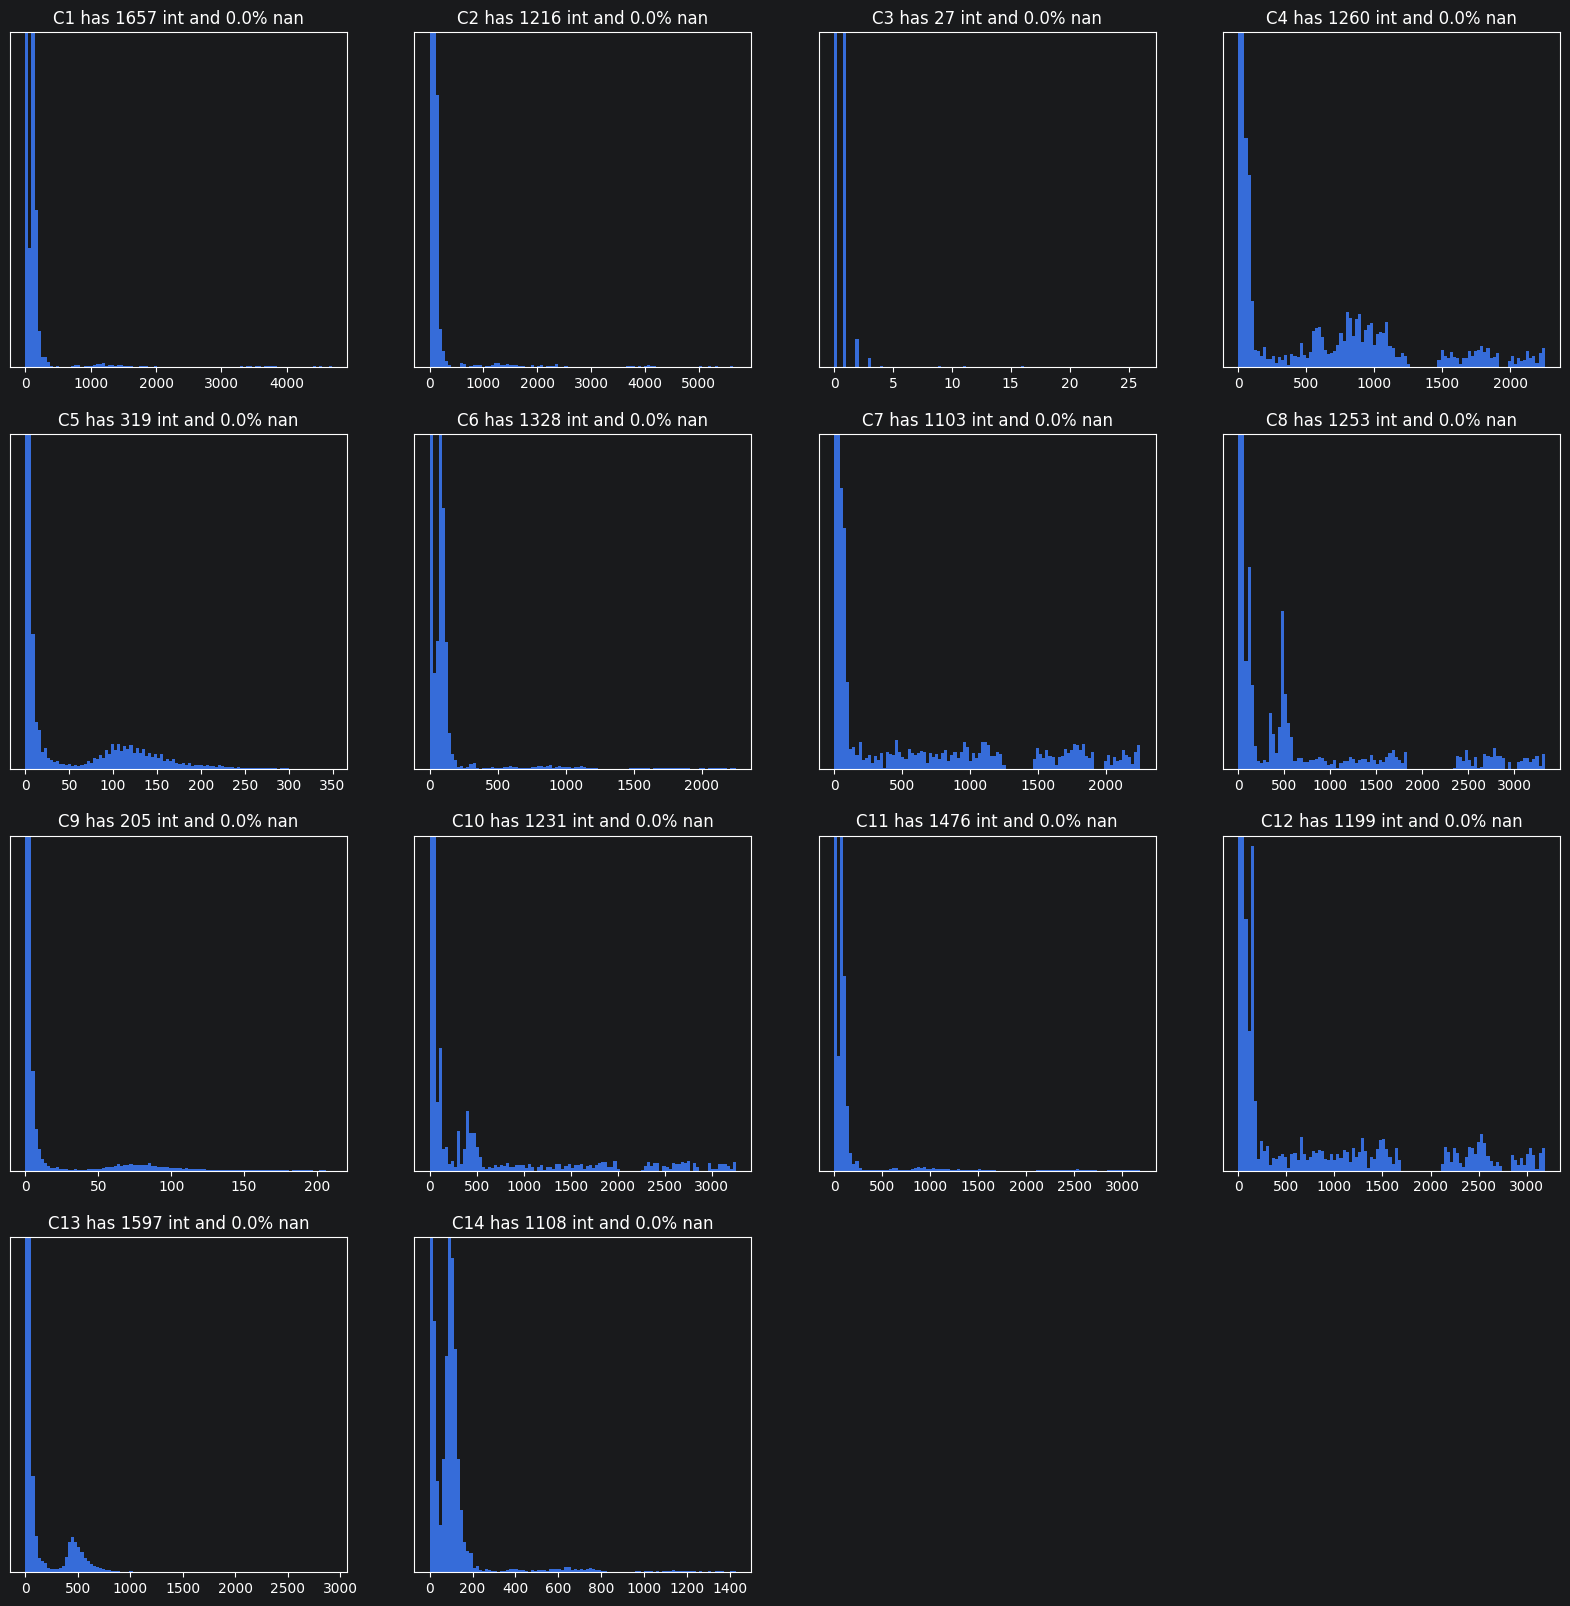

In [174]:
def make_plots2(Vs, df):
    col = 4
    row = len(Vs)//4+1
    plt.figure(figsize=(20,row*5))
    for i,v in enumerate(Vs):
        plt.subplot(row,col,i+1)
        idx = df[~df[v].isna()].index
        n = df[v].nunique()
        x = np.sum(df.loc[idx,v]!=df.loc[idx,v].astype(int))
        y = np.round(100*np.sum(df[v].isna())/len(df),2)
        t = 'int'
        if x!=0: t = 'float'
        plt.title(v+' has '+str(n)+' '+t+' and '+str(y)+'% nan')
        plt.yticks([])
        h = plt.hist(df.loc[idx,v],bins=100)
        if len(h[0])>1: plt.ylim((0,np.sort(h[0])[-2]))
    plt.show()
make_plots2(['C'+str(x) for x in range(1,15)], train_transaction)

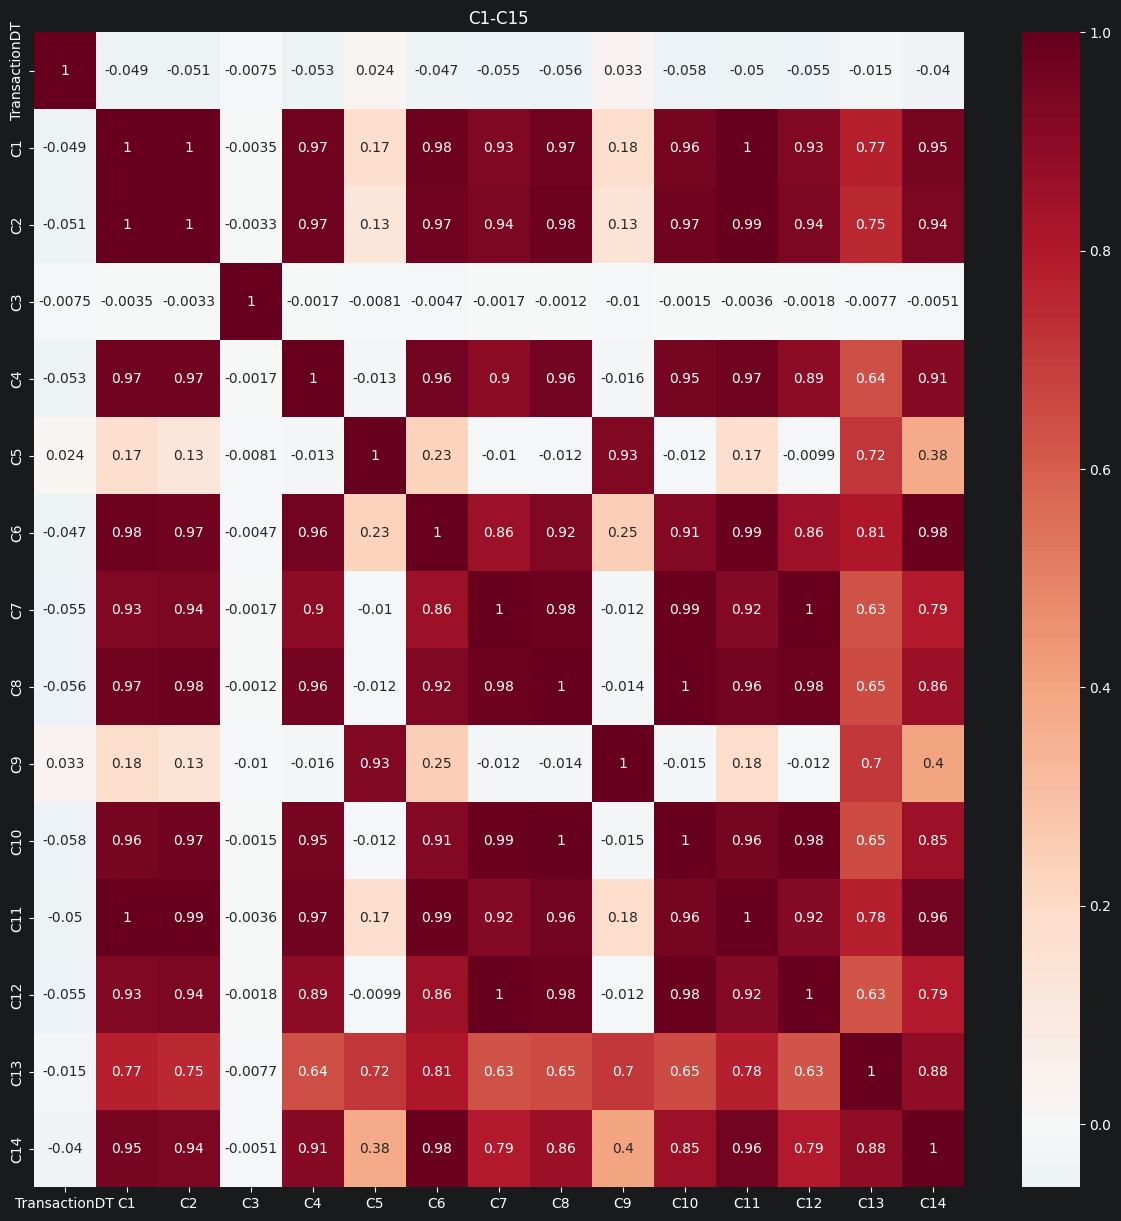

In [175]:
cols = ['TransactionDT'] + ['C'+str(x) for x in range(1,15)]
plt.figure(figsize=(15,15))
sns.heatmap(train_transaction[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('C1-C15')
plt.show()

In [176]:
c_grps = [
 [1, 2, 4, 6, 7, 8, 10, 11, 12, 13, 14],
 [5, 9],
 [3]
]

c_grps = reduce_group(c_grps, c='C')
print(c_grps)

[1, 5, 3]


# Process M columns

In [177]:
m_cols = train_df.columns[train_df.columns.str.match(r"^M\d+$")]
print(train_df[m_cols].dtypes)

M1    str
M2    str
M3    str
M4    str
M5    str
M6    str
M7    str
M8    str
M9    str
dtype: object


In [178]:
m_profile = pd.DataFrame({
    "nunique": train_df[m_cols].nunique(dropna=True),
    "nunique_incl_nan": train_df[m_cols].nunique(dropna=False),
    "null_pct": train_df[m_cols].isna().mean() * 100
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(m_profile)

    nunique  nunique_incl_nan   null_pct
M5        2                 3  59.349409
M7        2                 3  58.635317
M8        2                 3  58.633115
M9        2                 3  58.633115
M1        2                 3  45.907136
M2        2                 3  45.907136
M3        2                 3  45.907136
M6        2                 3  28.678836
M4        3                 4  47.658753


In [179]:
m_profile = pd.DataFrame({
    "nunique": test_df[m_cols].nunique(dropna=True),
    "nunique_incl_nan": test_df[m_cols].nunique(dropna=False),
    "null_pct": test_df[m_cols].isna().mean() * 100
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(m_profile)

    nunique  nunique_incl_nan   null_pct
M5        2                 3  61.108644
M7        2                 3  46.382904
M8        2                 3  46.380141
M9        2                 3  46.380141
M1        2                 3  34.861286
M2        2                 3  34.861286
M3        2                 3  34.861286
M6        2                 3  31.368033
M4        3                 4  46.921102


In [180]:
for c in m_cols:
    vc = df[c].value_counts(dropna=False)
    vp = df[c].value_counts(dropna=False, normalize=True).mul(100).round(2)
    print(f"\n")
    print(pd.DataFrame({"count": vc, "pct": vp}))



      count    pct
M1                
T    649436  59.19
NaN  447739  40.81
F        56   0.01


      count    pct
M2                
T    588323  53.62
NaN  447739  40.81
F     61169   5.57


      count    pct
M3                
T    518244  47.23
NaN  447739  40.81
F    131248  11.96


      count    pct
M4                
NaN  519189  47.32
M0   357789  32.61
M2   122947  11.21
M1    97306   8.87


      count    pct
M5                
NaN  660114  60.16
F    240155  21.89
T    196962  17.95


      count    pct
M6                
F    419433  38.23
T    349499  31.85
NaN  328299  29.92


      count    pct
M7                
NaN  581283  52.98
F    444604  40.52
T     71344   6.50


      count    pct
M8                
NaN  581256  52.97
F    323650  29.50
T    192325  17.53


      count    pct
M9                
NaN  581256  52.97
T    441935  40.28
F     74040   6.75


In [181]:
m_cols = [f"M{i}" for i in range(1, 10)]
tf_cols = [c for c in m_cols if c != "M4"]

# 1) M1-M3, M5-M9: keep missing as a separate state
tf_map = {"T": 1, "F": 0}
for c in tf_cols:
    train_df[c + "_isna"] = train_df[c].isna().astype("int8")
    test_df[c + "_isna"]  = test_df[c].isna().astype("int8")
    df[c + "_isna"] = df[c].isna().astype("int8")
    # # Fill NaN with -999
    # train_df[c] = train_df[c].map(tf_map).fillna(-999).astype("int8")  # -999 = missing
    # test_df[c]  = test_df[c].map(tf_map).fillna(-999).astype("int8")
    # df[c] = df[c].map(tf_map).fillna(-999).astype("int8")

    # Don't fill NaN
    train_df[c] = train_df[c].map(tf_map)
    test_df[c]  = test_df[c].map(tf_map)
    df[c] = df[c].map(tf_map)

train_df['M4_isna'] = train_df['M4'].isna().astype("int8")
test_df['M4_isna'] = test_df['M4'].isna().astype("int8")

# 2) M4: one-hot encoding (fit categories on train only)
train_m4 = train_df["M4"].fillna("__MISSING__")
test_m4  = test_df["M4"].fillna("__MISSING__")
df_m4    = df["M4"].fillna("__MISSING__")

# use train categories as schema
m4_categories = sorted(train_m4.unique())

train_m4_cat = pd.Categorical(train_m4, categories=m4_categories)
test_m4_cat  = pd.Categorical(test_m4,  categories=m4_categories)
df_m4_cat    = pd.Categorical(df_m4,    categories=m4_categories)

train_m4_oh = pd.get_dummies(train_m4_cat, prefix="M4", dtype="int8")
test_m4_oh  = pd.get_dummies(test_m4_cat,  prefix="M4", dtype="int8")
df_m4_oh    = pd.get_dummies(df_m4_cat,    prefix="M4", dtype="int8")

# align columns (important for unseen categories in test/df)
test_m4_oh = test_m4_oh.reindex(columns=train_m4_oh.columns, fill_value=0)
df_m4_oh   = df_m4_oh.reindex(columns=train_m4_oh.columns, fill_value=0)

# replace M4 with one-hot columns
train_df = pd.concat([train_df.drop(columns=["M4"]), train_m4_oh], axis=1)
test_df  = pd.concat([test_df.drop(columns=["M4"]),  test_m4_oh], axis=1)
df       = pd.concat([df.drop(columns=["M4"]),    df_m4_oh], axis=1)

In [182]:
train_transaction_v1 = train_transaction.copy()
Ms = ['M'+str(x) for x in range(1,10)]
mp = {'F':0,'T':1,'M0':0,'M1':1,'M2':2}
for c in Ms: train_transaction_v1[c] = train_transaction_v1[c].map(mp)

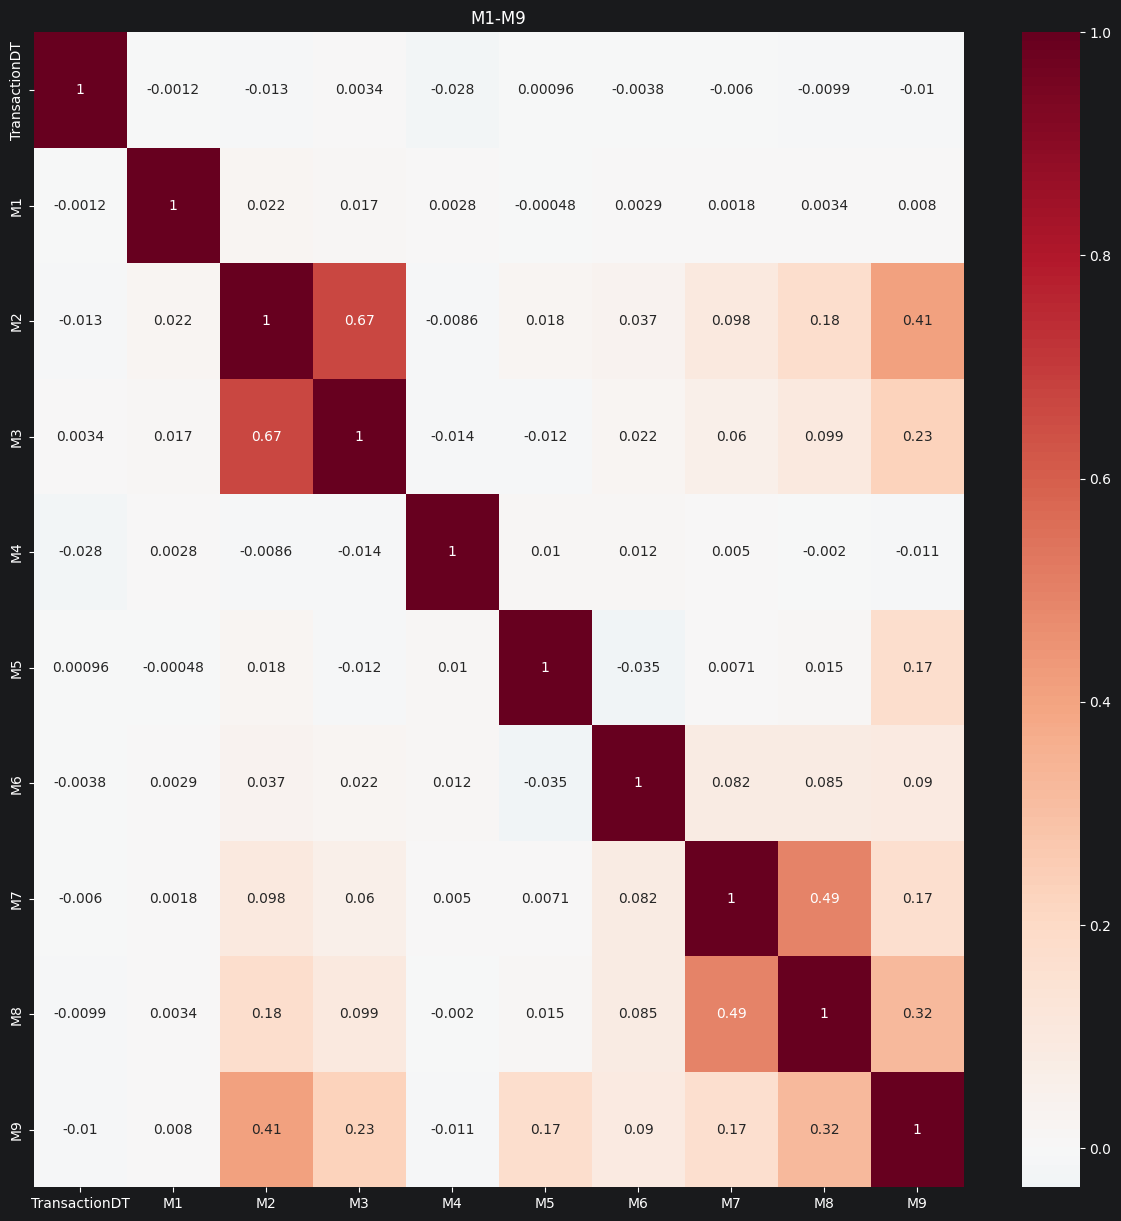

In [183]:
cols = ['TransactionDT'] + m_cols
plt.figure(figsize=(15,15))
sns.heatmap(train_transaction_v1[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('M1-M9')
plt.show()

In [184]:
# cols = ['TransactionDT'] + m_cols
# plt.figure(figsize=(15,15))
# sns.heatmap(train_df[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
# plt.title('M1-M9')
# plt.show()

In [185]:
m_grps = [
 [1, 2, 3],
 [7, 8, 9],
 [4],
 [5],
 [6]
]

m_grps = reduce_group(m_grps, c='M')
print(m_grps)

[1, 7, 4, 5, 6]


# Process V columns

# Approach 1

# Applying EDA for V columns

The V columns appear to be redundant and correlated. Therefore for each block of V columns with similar NAN structure, we could find subsets within the block that are correlated (r > 0.75). Then we can replace the entire block with one column from each subset.

For example in block V1-V11, we see that the subsets [[1],[2,3],[4,5],[6,7],[8,9],[10,11]] exist and we can choose [1, 3, 4, 6, 8, 11] to represent the V1-V11 block without losing that much information. Alternatively you could apply PCA on each block, but this subset reduce method performed better.

In [186]:
v_cols = train_df.columns[train_df.columns.str.match(r"^V\d+$")]
print(train_df[v_cols].dtypes)

V1      float64
V2      float64
V3      float64
V4      float64
V5      float64
         ...   
V335    float64
V336    float64
V337    float64
V338    float64
V339    float64
Length: 339, dtype: object


# NAN search
We will search all the columns of train_transaction.csv to determine which columns are related by the number of NANs present. We see that D1 relates to a subset of V281 thru V315, and D11 relates to V1 thru V11. Also we find groups of Vs with similar NAN structure. And we see that M1, M2, M3 related and M8, M9 related

In [187]:
nans_df = train_transaction.isna()
nans_groups={}
i_cols = ['V'+str(i) for i in range(1,340)]
for col in train_transaction.columns:
    cur_group = nans_df[col].sum()
    try:
        nans_groups[cur_group].append(col)
    except:
        nans_groups[cur_group]=[col]
del nans_df; x=gc.collect()

for k,v in nans_groups.items():
    print('####### NAN count =',k)
    print(v)

####### NAN count = 0
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']
####### NAN count = 8933
['card2']
####### NAN count = 1565
['card3']
####### NAN count = 1577
['card4']
####### NAN count = 4259
['card5']
####### NAN count = 1571
['card6']
####### NAN count = 65706
['addr1', 'addr2']
####### NAN count = 352271
['dist1']
####### NAN count = 552913
['dist2']
####### NAN count = 94456
['P_emaildomain']
####### NAN count = 453249
['R_emaildomain']
####### NAN count = 1269
['D1', 'V281', 'V282', 'V283', 'V288', 'V289', 'V296', 'V300', 'V301', 'V313', 'V314', 'V315']
####### NAN count = 280797
['D2']
####### NAN count = 262878
['D3']
####### NAN count = 168922
['D4']
####### NAN count = 309841
['D5']
####### NAN count = 517353
['D6']
####### NAN count = 551623
['D7']
####### NAN count = 515614
['D8', 'D9']
####### NAN count = 76022
['D10']
####### NAN count = 27

In [188]:
def make_plots(Vs):
    col = 4
    row = len(Vs)//4+1
    plt.figure(figsize=(20,row*5))
    idx = train_transaction[~train_transaction[Vs[0]].isna()].index
    for i,v in enumerate(Vs):
        plt.subplot(row,col,i+1)
        n = train_transaction[v].nunique()
        x = np.sum(train_transaction.loc[idx,v]!=train_transaction.loc[idx,v].astype(int))
        y = np.round(100*np.sum(train_transaction[v].isna())/len(train_transaction),2)
        t = 'int'
        if x!=0: t = 'float'
        plt.title(v+' has '+str(n)+' '+t+' and '+str(y)+'% nan')
        plt.yticks([])
        h = plt.hist(train_transaction.loc[idx,v],bins=100)
        if len(h[0])>1: plt.ylim((0,np.sort(h[0])[-2]))
    plt.show()

In [189]:
# For example take the group: nan = 279287
####### NAN count = 279287
# ['D11', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11']

Vs = nans_groups[279287]
print(Vs)
Vtitle = 'V1 - V11, D11'

['D11', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11']


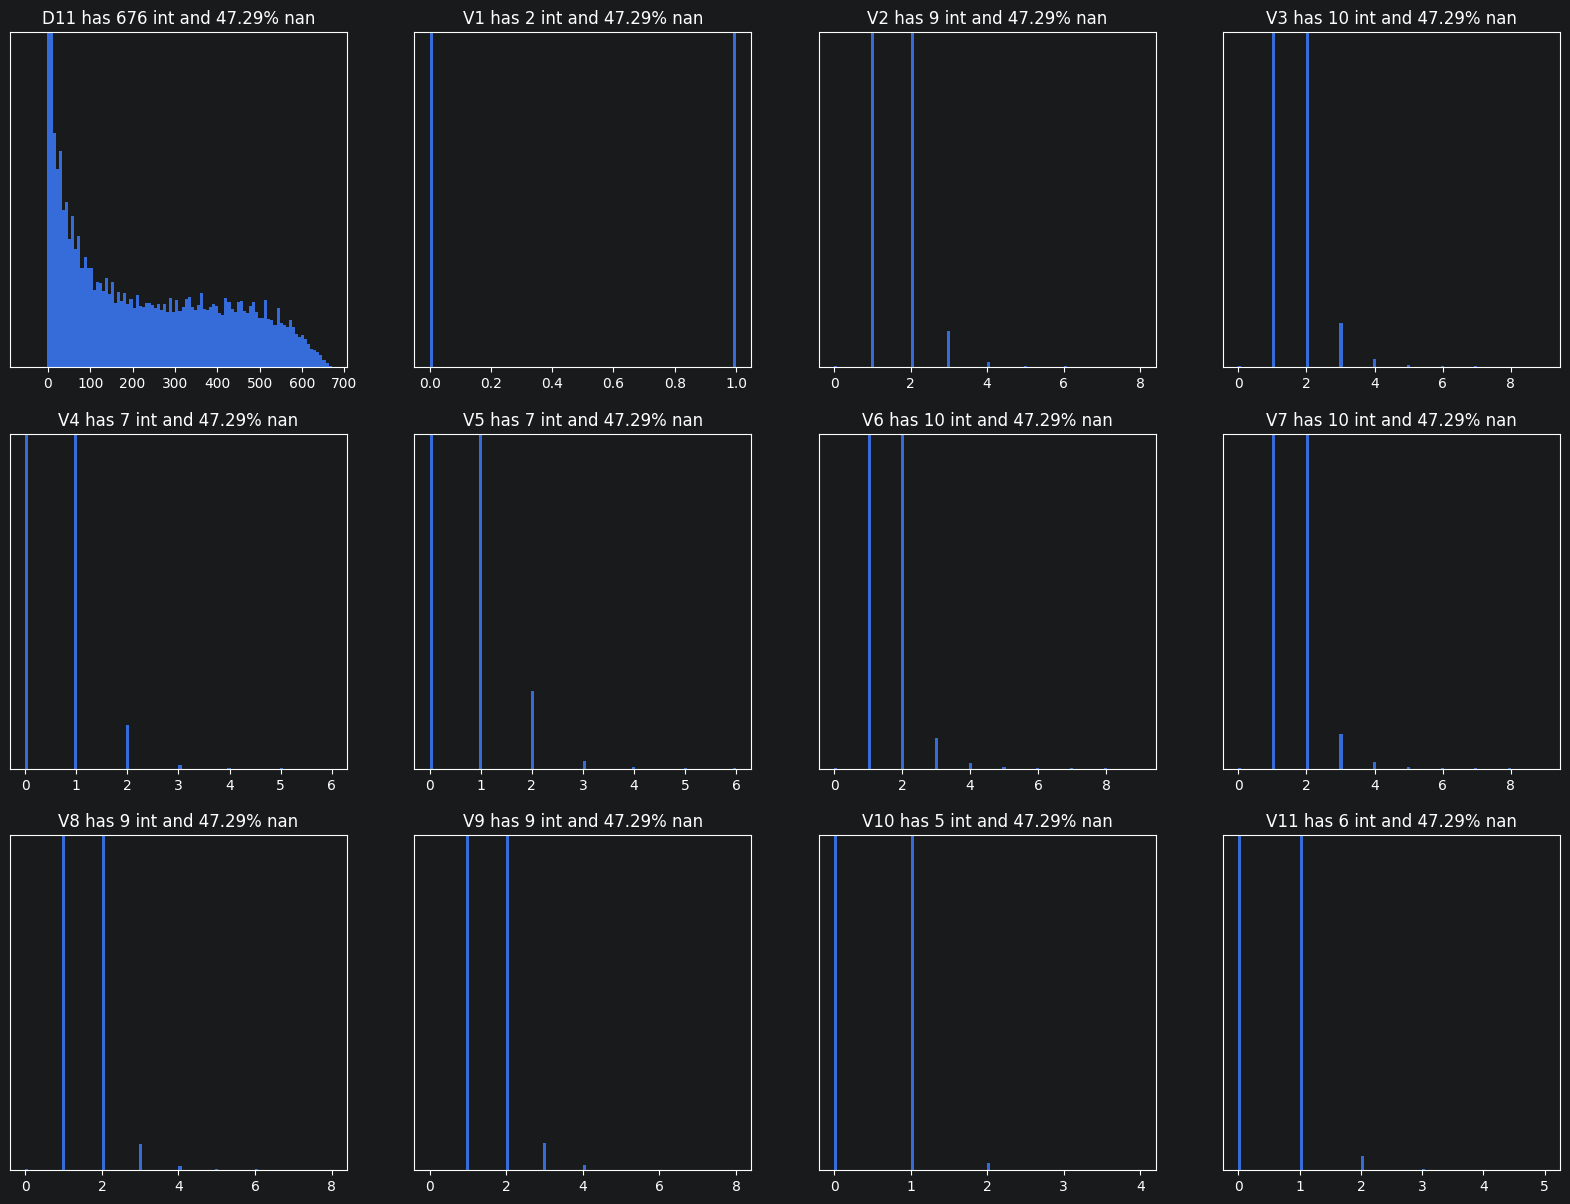

In [190]:
make_plots(Vs)

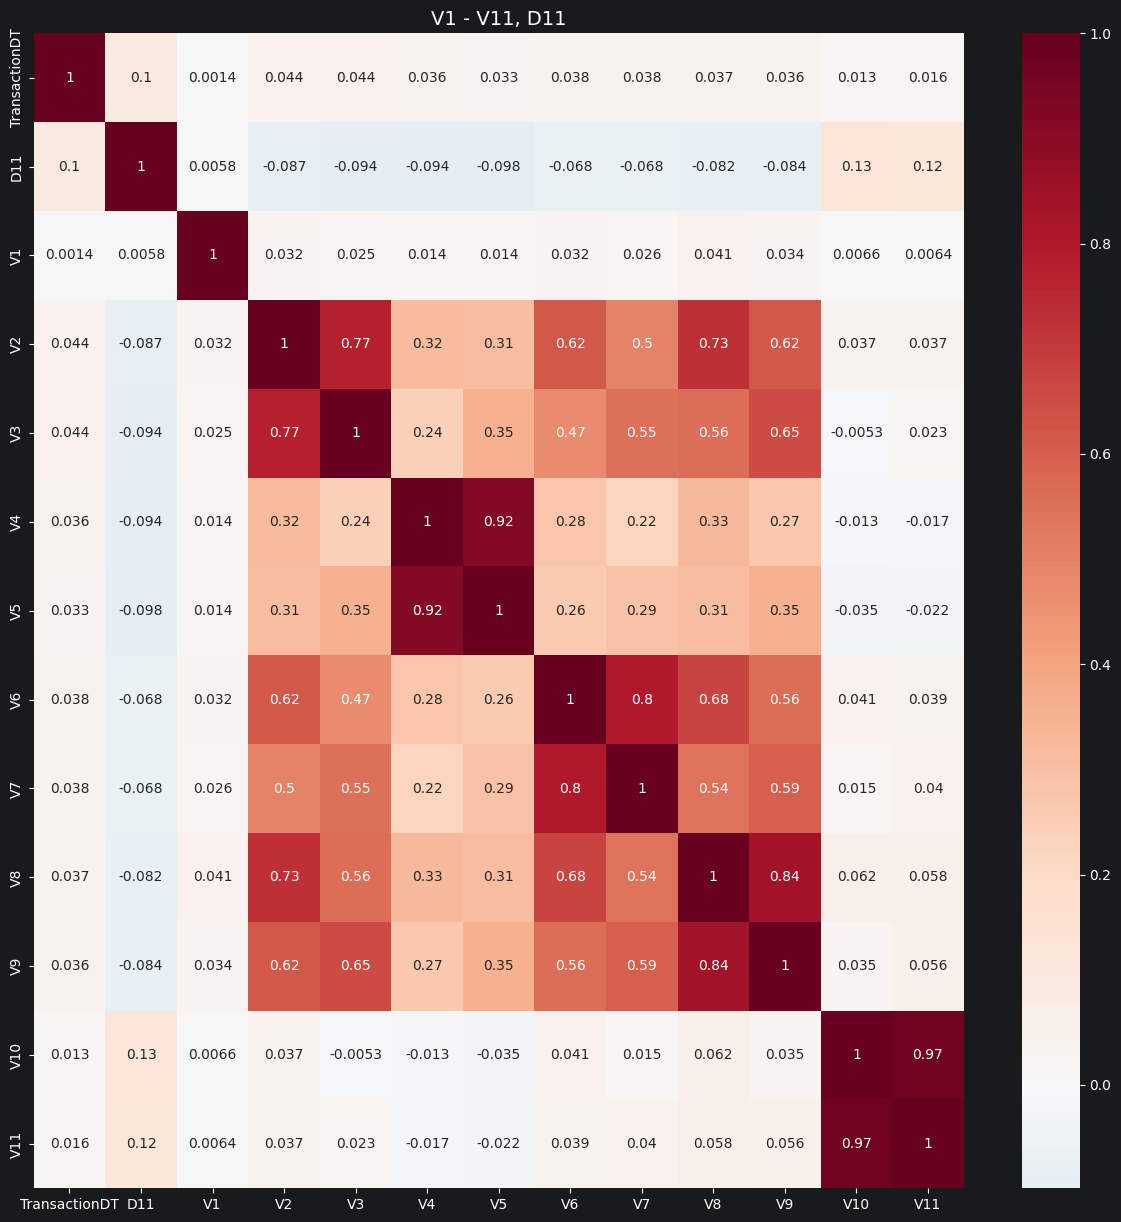

In [191]:
make_corr(Vs,Vtitle)

In [192]:
grp = [[1], [2, 3], [4, 5], [6, 7], [8, 9], [10, 11]]
grp1 = reduce_group(grp)
print(grp1)

[1, 3, 4, 6, 8, 11]


# V Reduced
Wow, even this reduced set still has much internal correlation. These V columns are highly redundant!

In [193]:
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]
v += [96, 98, 99, 104]
v += [107, 108, 111, 115, 117, 120, 121, 123]
v += [124, 127, 129, 130, 136]
v += [138, 139, 142, 147, 156, 162]
v += [165, 160, 166]
v += [178, 176, 173, 182]
v += [187, 203, 205, 207, 215]
v += [169, 171, 175, 180, 185, 188, 198, 210, 209]
v += [218, 223, 224, 226, 228, 229, 235]
v += [240, 258, 257, 253, 252, 260, 261]
v += [264, 266, 267, 274, 277]
v += [220, 221, 234, 238, 250, 271]
v += [294, 284, 285, 286, 291, 297]
v += [303, 305, 307, 309, 310, 320]
v += [281, 283, 289, 296, 301, 314]
v += [332, 325, 335, 338]

In [194]:
print('Reduced set has',len(v),'columns')

Reduced set has 128 columns


In [195]:
v_cols = [f"V{i}" for i in v if f"V{i}" in train_df.columns]
print(v_cols)

['V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17', 'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41', 'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67', 'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89', 'V91', 'V96', 'V98', 'V99', 'V104', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121', 'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139', 'V142', 'V147', 'V156', 'V162', 'V165', 'V160', 'V166', 'V178', 'V176', 'V173', 'V182', 'V187', 'V203', 'V205', 'V207', 'V215', 'V169', 'V171', 'V175', 'V180', 'V185', 'V188', 'V198', 'V210', 'V209', 'V218', 'V223', 'V224', 'V226', 'V228', 'V229', 'V235', 'V240', 'V258', 'V257', 'V253', 'V252', 'V260', 'V261', 'V264', 'V266', 'V267', 'V274', 'V277', 'V220', 'V221', 'V234', 'V238', 'V250', 'V271', 'V294', 'V284', 'V285', 'V286', 'V291', 'V297', 'V303', 'V305', 'V307', 'V309', 'V310', 'V320', 'V281', 'V283', 'V289', 'V296', 'V301', 'V314', 'V332', 'V325', 'V335', 'V338']


In [196]:
v_profile = pd.DataFrame({
    "nunique": train_df[v_cols].nunique(dropna=True),
    "nunique_incl_nan": train_df[v_cols].nunique(dropna=False),
    "null_pct": train_df[v_cols].isna().mean() * 100,
    "zero_pct": (train_df[v_cols] == 0).mean() * 100,
    "min": train_df[v_cols].min(),
    "p50": train_df[v_cols].median(),
    "p95": train_df[v_cols].quantile(0.95),
    "max": train_df[v_cols].max(),
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

train_null_pct = v_profile["null_pct"]

print(v_profile)

      nunique  nunique_incl_nan   null_pct   zero_pct  min  p50         p95  \
V1          2                 3  47.293494   0.002879  0.0  1.0    1.000000   
V41         2                 3  28.612626   0.052156  0.0  1.0    1.000000   
V88         2                 3  15.098723   0.064009  0.0  1.0    1.000000   
V65         2                 3  13.055170   0.029295  0.0  1.0    1.000000   
V14         2                 3  12.881939   0.043519  0.0  1.0    1.000000   
...       ...               ...        ...        ...  ...  ...         ...   
V264    13358             13359  77.913435  15.296847  0.0  0.0  400.000000   
V203    14951             14952  76.355370  16.630034  0.0  0.0  500.000000   
V310    19136             19137   0.002032  60.083144  0.0  0.0  554.000000   
V127    24414             24415   0.053172  62.075050  0.0  0.0  720.000000   
V307    37367             37368   0.002032  53.620415  0.0  0.0  935.630008   

           max  
V1         1.0  
V41        1.0  


In [197]:
v_profile = pd.DataFrame({
    "nunique": test_df[v_cols].nunique(dropna=True),
    "nunique_incl_nan": test_df[v_cols].nunique(dropna=False),
    "null_pct": test_df[v_cols].isna().mean() * 100,
    "zero_pct": (test_df[v_cols] == 0).mean() * 100,
    "min": test_df[v_cols].min(),
    "p50": test_df[v_cols].median(),
    "p95": test_df[v_cols].quantile(0.95),
    "max": test_df[v_cols].max(),
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

test_null_pct = v_profile["null_pct"]

print(v_profile)

      nunique  nunique_incl_nan   null_pct   zero_pct  min  p50         p95  \
V107        1                 1   0.000000   0.000000  1.0  1.0    1.000000   
V1          2                 3  34.837406   0.000197  0.0  1.0    1.000000   
V41         2                 3  15.167824   0.010065  0.0  1.0    1.000000   
V65         2                 3   2.545733   0.009079  0.0  1.0    1.000000   
V14         2                 3   2.484552   0.014999  0.0  1.0    1.000000   
...       ...               ...        ...        ...  ...  ...         ...   
V264    12700             12701  74.989096  16.972869  0.0  0.0  500.000000   
V203    13940             13941  73.014322  18.541873  0.0  0.0  503.564191   
V310    15384             15385   0.000592  59.992185  0.0  0.0  573.982504   
V127    18871             18871   0.000000  60.876353  0.0  0.0  820.000000   
V307    29592             29593   0.000592  52.746151  0.0  0.0  954.000000   

            max  
V107        1.0  
V1          1.0

In [198]:
max(train_null_pct)

86.12371727571374

In [199]:
TARGET = "isFraud"
NULL_DROP_THR = 0.9995      # drop if max(train_null, test_null) > this
NEAR_CONST_THR = 0.999      # drop if top value frequency > this
HIGH_NULL_RAW_DROP = 0.95   # for very sparse raw V cols, keep _isna flag, drop raw
CORR_THR = 0.75

In [200]:
# =========================
# 1) Basic pruning
# =========================
def basic_prune(train_df, test_df, cols, null_drop_thr=0.9995, near_const_thr=0.999):
    tr_null = train_df[cols].isna().mean()
    te_null = test_df[cols].isna().mean()
    max_null = pd.concat([tr_null, te_null], axis=1).max(axis=1)

    drop_null = max_null[max_null > null_drop_thr].index.tolist()
    drop_const = [c for c in cols if train_df[c].nunique(dropna=False) <= 1]

    top_freq = train_df[cols].apply(lambda s: s.value_counts(dropna=False, normalize=True).iloc[0])
    drop_near_const = top_freq[top_freq > near_const_thr].index.tolist()

    drop_all = set(drop_null) | set(drop_const) | set(drop_near_const)
    keep = [c for c in cols if c not in drop_all]

    stats = pd.DataFrame({
        "train_null": tr_null,
        "test_null": te_null,
        "max_null": max_null,
        "top_freq_train": top_freq
    })
    return keep, stats, sorted(drop_all)

keep1, v_stats, dropped_basic = basic_prune(
    train_df, test_df, v_cols,
    null_drop_thr=NULL_DROP_THR,
    near_const_thr=NEAR_CONST_THR
)

print(f"After basic prune: {len(v_cols)} -> {len(keep1)}")

After basic prune: 128 -> 126


In [201]:
print(f"Drop basic: {dropped_basic} -> {len(dropped_basic)}")

Drop basic: ['V107', 'V305'] -> 2


In [202]:
print(v_stats)

      train_null  test_null  max_null  top_freq_train
V1      0.472935   0.348374  0.472935        0.527036
V3      0.472935   0.348374  0.472935        0.492063
V4      0.472935   0.348374  0.472935        0.472935
V6      0.472935   0.348374  0.472935        0.505685
V8      0.472935   0.348374  0.472935        0.513879
...          ...        ...       ...             ...
V314    0.002149   0.011903  0.011903        0.801424
V332    0.860550   0.849157  0.860550        0.860550
V325    0.860550   0.849157  0.860550        0.860550
V335    0.860550   0.849157  0.860550        0.860550
V338    0.860550   0.849157  0.860550        0.860550

[128 rows x 4 columns]


In [203]:
# =========================
# 2) Add _isna flags + drop very sparse raw cols
# =========================
def add_isna_flags(train_df, test_df, cols):
    tr_flags = train_df[cols].isna().astype("int8").add_suffix("_isna")
    te_flags = test_df[cols].isna().astype("int8").add_suffix("_isna")

    train_fe = pd.concat([train_df, tr_flags], axis=1).copy()  # copy() de-fragments
    test_fe  = pd.concat([test_df, te_flags], axis=1).copy()

    return train_fe, test_fe, tr_flags.columns.tolist()

In [204]:
# drop very sparse raw V columns (keep their _isna flags)
drop_sparse_raw = [c for c in keep1 if v_stats.loc[c, "train_null"] > HIGH_NULL_RAW_DROP]
keep2_raw = [c for c in keep1 if c not in drop_sparse_raw]

print(f"Drop very sparse raw V cols (> {HIGH_NULL_RAW_DROP:.0%} null): {len(drop_sparse_raw)}")
print(f"Raw V remaining: {len(keep2_raw)}")

Drop very sparse raw V cols (> 95% null): 0
Raw V remaining: 126


In [205]:
def _to_col(gg, c='V'):
    return gg if isinstance(gg, str) else f"{c}{gg}"

In [206]:
def reduce_group_v2(grps, train_df, c='V', null_drop_thr=None):
    use = []
    null_rate = train_df.isna().mean()

    for g in grps:
        candidates = list(g)

        if null_drop_thr is not None:
            filtered = [gg for gg in candidates if null_rate[_to_col(gg, c)] <= null_drop_thr]
            if len(filtered) > 0:
                candidates = filtered

        best = max(
            candidates,
            key=lambda gg: (
                train_df[_to_col(gg, c)].nunique(dropna=True),   # maximize
                -null_rate[_to_col(gg, c)]                       # minimize null
            )
        )
        use.append(best)

    return use

In [207]:
def make_corr_groups(train_df, cols, corr_thr=CORR_THR):
    X = train_df[cols].copy()
    X = X.fillna(X.median(numeric_only=True))
    corr = X.corr().abs()

    # graph components for pairs above threshold
    neighbors = {c: set() for c in cols}
    iu = np.triu_indices(len(cols), k=1)
    for i, j in zip(*iu):
        ci, cj = cols[i], cols[j]
        if corr.iat[i, j] > corr_thr:
            neighbors[ci].add(cj)
            neighbors[cj].add(ci)

    groups, seen = [], set()
    for c in cols:
        if c in seen:
            continue
        stack, comp = [c], []
        seen.add(c)
        while stack:
            u = stack.pop()
            comp.append(u)
            for v in neighbors[u]:
                if v not in seen:
                    seen.add(v)
                    stack.append(v)
        groups.append(comp)
    return groups

In [208]:
# ---- Apply pipeline ----
groups = make_corr_groups(train_df, keep2_raw)

keep_rep = reduce_group_v2(groups, train_df, c='V', null_drop_thr=NULL_DROP_THR)
keep_cols = [_to_col(x, 'V') for x in keep_rep]


print("groups length:", len(groups))
print("after reduce_group_v2:", len([_to_col(x, 'V') for x in keep_rep]))

groups length: 88
after reduce_group_v2: 88


In [209]:
print("groups: ", groups)

groups:  [['V1'], ['V3'], ['V4'], ['V6'], ['V8'], ['V11'], ['V13'], ['V14'], ['V17', 'V40', 'V80', 'V59'], ['V20'], ['V23'], ['V26'], ['V27'], ['V30', 'V91', 'V70', 'V48'], ['V36'], ['V37'], ['V41'], ['V44'], ['V47'], ['V54'], ['V56'], ['V62'], ['V65'], ['V67'], ['V68'], ['V76'], ['V78'], ['V82'], ['V86'], ['V88'], ['V89'], ['V96', 'V332', 'V180', 'V215', 'V165', 'V182', 'V307', 'V296', 'V104', 'V297', 'V127', 'V136', 'V320', 'V294', 'V203', 'V178', 'V338'], ['V98', 'V284'], ['V99', 'V285'], ['V108'], ['V111'], ['V115'], ['V117'], ['V120'], ['V121'], ['V123'], ['V124'], ['V129', 'V266', 'V309'], ['V130', 'V310'], ['V138'], ['V139'], ['V142'], ['V147'], ['V156'], ['V162'], ['V160'], ['V166'], ['V176'], ['V173'], ['V187', 'V207', 'V205'], ['V169'], ['V171'], ['V175'], ['V185'], ['V188'], ['V198'], ['V210'], ['V209'], ['V218', 'V274', 'V264', 'V224', 'V253', 'V229', 'V258', 'V257', 'V261', 'V267'], ['V223'], ['V226'], ['V228'], ['V235'], ['V240'], ['V252'], ['V260'], ['V277'], ['V220'], [

In [210]:
print("Kept columns: ", keep_cols)

Kept columns:  ['V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V80', 'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V41', 'V44', 'V47', 'V54', 'V56', 'V62', 'V65', 'V67', 'V68', 'V76', 'V78', 'V82', 'V86', 'V88', 'V89', 'V307', 'V284', 'V285', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121', 'V123', 'V124', 'V309', 'V310', 'V138', 'V139', 'V142', 'V147', 'V156', 'V162', 'V160', 'V166', 'V176', 'V173', 'V207', 'V169', 'V171', 'V175', 'V185', 'V188', 'V198', 'V210', 'V209', 'V264', 'V223', 'V226', 'V228', 'V235', 'V240', 'V252', 'V260', 'V277', 'V220', 'V221', 'V234', 'V238', 'V250', 'V271', 'V286', 'V291', 'V303', 'V281', 'V283', 'V289', 'V301', 'V314', 'V325', 'V335']


In [211]:
# V-columns to drop: startswith('V') but not selected in keep_cols
v_drop_train = [c for c in train_df.columns if c.startswith("V") and c not in keep_cols]
v_drop_test  = [c for c in test_df.columns  if c.startswith("V") and c not in keep_cols]

train_fe = train_df.drop(columns=v_drop_train)
test_fe  = test_df.drop(columns=v_drop_test)

print(f"dropped {len(v_drop_train)} V cols from train_fe")
print(f"dropped {len(v_drop_test)} V cols from test_fe")

dropped 251 V cols from train_fe
dropped 251 V cols from test_fe


In [212]:
train_fe, test_fe, isna_flags = add_isna_flags(train_df, test_df, keep_cols)

In [213]:
# Only if model cannot handle NaN such as (logistic/NN/sklearn trees)

med = train_fe[keep_cols].median()
train_fe[keep_cols] = train_fe[keep_cols].fillna(med)
test_fe[keep_cols]  = test_fe[keep_cols].fillna(med)

# Process ID columns

In [214]:
train_fe = pd.merge(train_fe, train_identity,on='TransactionID',how='left')

test_fe = pd.merge(test_fe, test_identity.rename(
    columns=lambda c: c.replace("id-", "id_") if c.startswith("id-") else c
),on='TransactionID',how='left')


ids = ['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,39)]
for c in ids: print (c,train_fe[c].unique()[:10])

id_01 [ nan   0.  -5. -15. -10. -20. -40. -30. -25. -55.]
id_02 [    nan  70787.  98945. 191631. 221832.   7460.  61141.  31964. 116098.
 257037.]
id_03 [nan  0.  3.  2.  5.  1.  6.  9.  4. -5.]
id_04 [ nan   0. -11.  -5.  -8.  -1.  -6.  -9.  -3. -13.]
id_05 [nan  0.  1.  3.  2.  9. 12.  6.  4. 21.]
id_06 [ nan  -5.   0.  -6. -10. -11.  -1.  -4. -43.  -9.]
id_07 [nan 22.  6. -1.  4.  2. 17. 12. 27.  5.]
id_08 [  nan  -34.  -55. -100.  -15.  -33.  -13.  -36.  -44.  -26.]
id_09 [nan  0.  3.  2.  1.  5. -8.  7.  4.  6.]
id_10 [ nan   0.  -9. -42.  -6. -29.  -8.  -1.  -5. -11.]
id_11 [         nan 100.          93.75        95.08000183  95.65000153
  94.29000092  96.19000244  90.56999969  97.54000092  96.43000031]
id_12 <StringArray>
[nan, 'NotFound', 'Found']
Length: 3, dtype: str
id_13 [nan 49. 52. 14. 20. 55. 43. 18. 41. 63.]
id_14 [  nan -480. -300. -360. -420. -540. -600.  480. -240.  300.]
id_15 <StringArray>
[nan, 'New', 'Found', 'Unknown']
Length: 4, dtype: str
id_16 <StringArray>


In [215]:
train_fe['DeviceType']

0            NaN
1            NaN
2            NaN
3            NaN
4         mobile
           ...  
590535       NaN
590536       NaN
590537       NaN
590538       NaN
590539       NaN
Name: DeviceType, Length: 590540, dtype: str

In [216]:
id_profile = pd.DataFrame({
    "nunique": train_fe[ids].nunique(dropna=True),
    "nunique_incl_nan": train_fe[ids].nunique(dropna=False),
    "null_pct": train_fe[ids].isna().mean() * 100,
    "zero_pct": (train_fe[ids] == 0).mean() * 100,
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(id_profile)

       nunique  nunique_incl_nan   null_pct   zero_pct
id_27        2                 3  99.124699   0.000000
id_16        2                 3  78.098012   0.000000
id_28        2                 3  76.127273   0.000000
id_29        2                 3  76.127273   0.000000
id_35        2                 3  76.126088   0.000000
id_36        2                 3  76.126088   0.000000
id_37        2                 3  76.126088   0.000000
id_38        2                 3  76.126088   0.000000
id_12        2                 3  75.576083   0.000000
id_23        3                 4  99.124699   0.000000
id_15        3                 4  76.126088   0.000000
id_32        4                 5  86.861855   0.001016
id_34        4                 5  86.824771   0.000000
id_24       12                13  99.196159   0.000000
id_04       15                16  88.768923  11.132015
id_18       18                19  92.360721   0.000000
id_03       24                25  88.768923  10.821113
id_22     

In [217]:
id_profile = pd.DataFrame({
    "nunique": test_fe[ids].nunique(dropna=True),
    "nunique_incl_nan": test_fe[ids].nunique(dropna=False),
    "null_pct": test_fe[ids].isna().mean() * 100,
    "zero_pct": (test_fe[ids] == 0).mean() * 100,
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(id_profile)

       nunique  nunique_incl_nan   null_pct   zero_pct
id_27        2                 3  99.000969   0.000000
id_34        2                 3  85.755618   0.000000
id_16        2                 3  75.182705   0.000000
id_28        2                 3  73.005639   0.000000
id_29        2                 3  73.005639   0.000000
id_35        2                 3  72.966364   0.000000
id_36        2                 3  72.966364   0.000000
id_37        2                 3  72.966364   0.000000
id_38        2                 3  72.966364   0.000000
id_12        2                 3  71.993385   0.000000
id_23        3                 4  99.000969   0.000000
id_15        3                 4  72.966364   0.000000
id_32        5                 6  86.052446   0.000000
id_24       15                16  99.064519   0.000000
id_04       15                16  86.879380  12.956812
id_18       17                18  89.959364   0.000000
id_03       22                23  86.879380  12.612815
id_22     

In [218]:
train_fe, test_fe, isna_flags = add_isna_flags(train_fe, test_fe, ids + ['DeviceInfo', 'DeviceType'])

In [219]:
# boolean = ['id_12','id_15','id_16','id_27','id_28','id_29','id_35','id_36','id_37','id_38']
cats = ['id_23','id_30','id_31','id_33','id_34']
# mp = {'Unknown':0,'NotFound':1,'Found':2,'New':3,'F':0,'T':1}
# for c in boolean: train_identity[c] = train_identity[c].map(mp)

In [220]:
def minify_identity_df(df):

    df['id_12'] = df['id_12'].map({'Found':1, 'NotFound':0})
    df['id_15'] = df['id_15'].map({'New':2, 'Found':1, 'Unknown':0})
    df['id_16'] = df['id_16'].map({'Found':1, 'NotFound':0})

    # df['id_23'] = df['id_23'].map({'TRANSPARENT':4, 'IP_PROXY':3, 'IP_PROXY:ANONYMOUS':2, 'IP_PROXY:HIDDEN':1})

    df['id_27'] = df['id_27'].map({'Found':1, 'NotFound':0})
    df['id_28'] = df['id_28'].map({'New':2, 'Found':1})

    df['id_29'] = df['id_29'].map({'Found':1, 'NotFound':0})

    df['id_35'] = df['id_35'].map({'T':1, 'F':0})
    df['id_36'] = df['id_36'].map({'T':1, 'F':0})
    df['id_37'] = df['id_37'].map({'T':1, 'F':0})
    df['id_38'] = df['id_38'].map({'T':1, 'F':0})

    df['id_34'] = df['id_34'].fillna(':0')
    df['id_34'] = df['id_34'].apply(lambda x: x.split(':')[1]).astype(np.int8)
    df['id_34'] = np.where(df['id_34']==0, np.nan, df['id_34'])

    tmp = df["id_33"].str.split("x", expand=True)
    df["id_33_0"] = pd.to_numeric(tmp[0], errors="coerce").fillna(0).astype("int16")
    df["id_33_1"] = pd.to_numeric(tmp[1], errors="coerce").fillna(0).astype("int16")

    return df

In [221]:
train_fe = minify_identity_df(train_fe)
test_fe = minify_identity_df(test_fe)

In [222]:
for col in ["id_30", "id_31", "DeviceInfo"]:
    train_s = train_fe[col].fillna("__MISSING__")
    test_s  = test_fe[col].fillna("__MISSING__")

    # fit on train only
    freq = train_s.value_counts(normalize=True)

    train_fe[col] = train_s.map(freq).astype("float32")
    test_fe[col]  = test_s.map(freq).fillna(0).astype("float32")  # unseen -> 0

In [223]:
for col in ["id_23", "DeviceType"]:
    train_s = train_fe[col].fillna("__MISSING__").astype(str)
    test_s  = test_fe[col].fillna("__MISSING__").astype(str)

    # Fit category space on train only
    categories = sorted(train_s.unique())
    train_cat = pd.Categorical(train_s, categories=categories)
    test_cat  = pd.Categorical(test_s, categories=categories)

    train_oh = pd.get_dummies(train_cat, prefix=col, dtype="int8")
    test_oh  = pd.get_dummies(test_cat,  prefix=col, dtype="int8")

    # Ensure same columns in test
    test_oh = test_oh.reindex(columns=train_oh.columns, fill_value=0)

    train_fe = pd.concat([train_fe.drop(columns=[col]), train_oh], axis=1)
    test_fe  = pd.concat([test_fe.drop(columns=[col]), test_oh], axis=1)

In [224]:
print(train_fe.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'DeviceType_isna', 'id_33_0', 'id_33_1', 'id_23_IP_PROXY:ANONYMOUS',
       'id_23_IP_PROXY:HIDDEN', 'id_23_IP_PROXY:TRANSPARENT',
       'id_23___MISSING__', 'DeviceType___MISSING__', 'DeviceType_desktop',
       'DeviceType_mobile'],
      dtype='str', length=623)


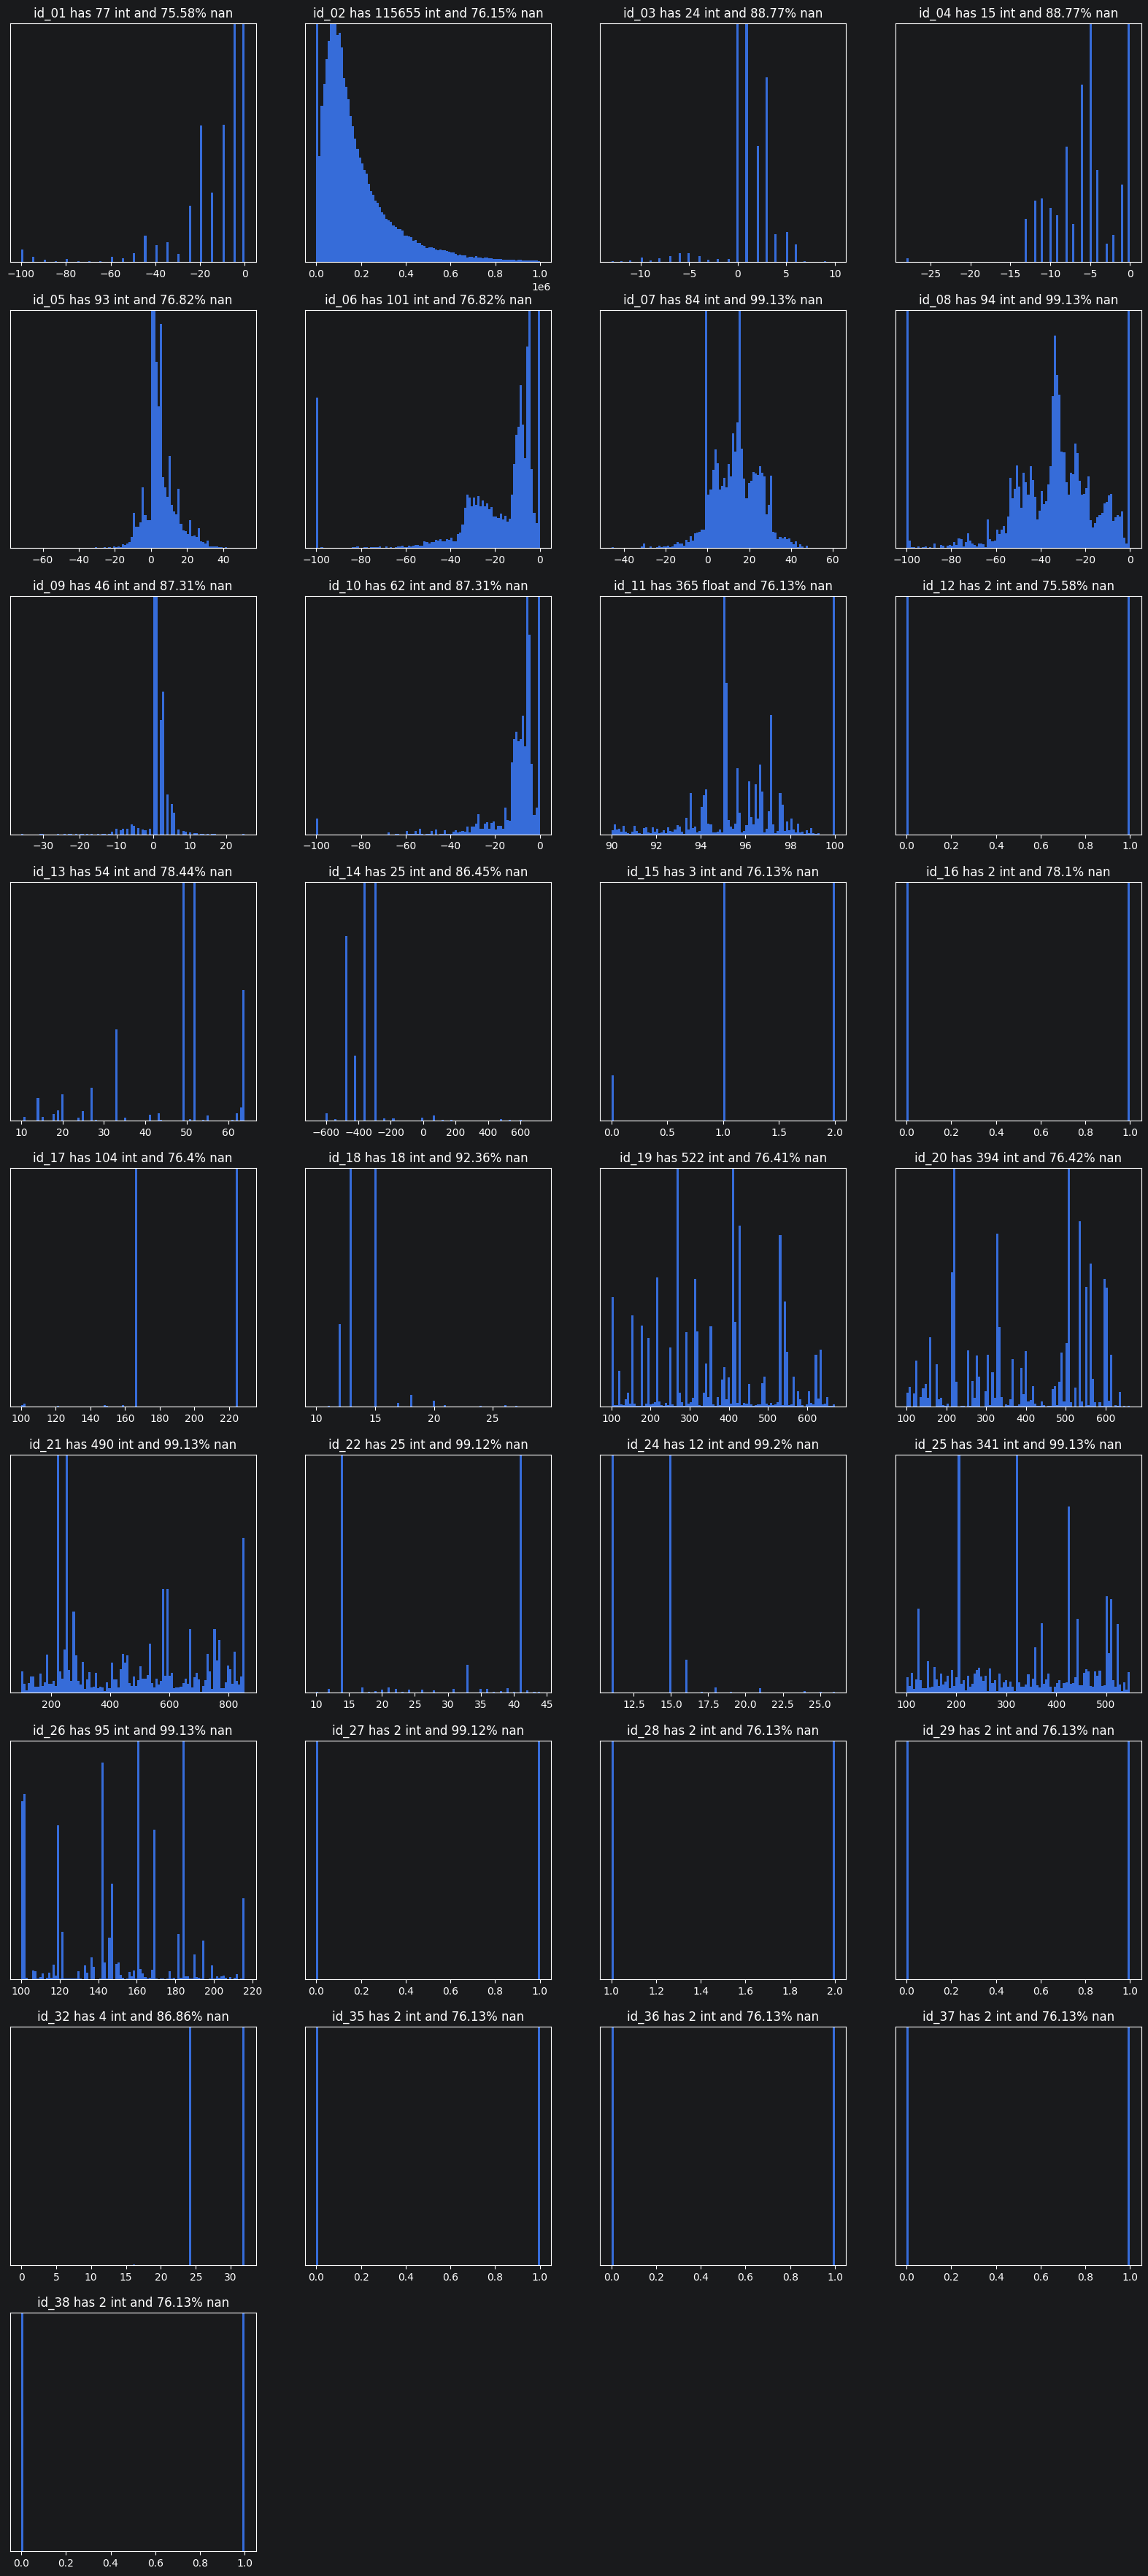

In [225]:
make_plots2([x for x in ids if x not in cats], train_fe)

In [226]:
# cols = ['TransactionDT'] + [x for x in ids if x not in cats]
# plt.figure(figsize=(15,15))
# sns.heatmap(train_fe[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
# plt.title('ID1-ID38')
# plt.show()

# Process cards columns

In [227]:
card_cols = train_fe.columns[train_fe.columns.str.match(r"^card\d+$")]
print(train_fe[card_cols].dtypes)

card1      int64
card2    float64
card3    float64
card4        str
card5    float64
card6        str
dtype: object


In [228]:
card_profile = pd.DataFrame({
    "nunique": train_fe[card_cols].nunique(dropna=True),
    "nunique_incl_nan": train_fe[card_cols].nunique(dropna=False),
    "null_pct": train_fe[card_cols].isna().mean() * 100
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(card_profile)

       nunique  nunique_incl_nan  null_pct
card4        4                 5  0.267044
card6        4                 5  0.266028
card3      114               115  0.265012
card5      119               120  0.721204
card2      500               501  1.512683
card1    13553             13553  0.000000


In [229]:
card_profile = pd.DataFrame({
    "nunique": test_fe[card_cols].nunique(dropna=True),
    "nunique_incl_nan": test_fe[card_cols].nunique(dropna=False),
    "null_pct": test_fe[card_cols].isna().mean() * 100
}).sort_values(["nunique", "null_pct"], ascending=[True, False])

print(card_profile)

       nunique  nunique_incl_nan  null_pct
card6        3                 4  0.593458
card4        4                 5  0.609050
card5      102               103  0.897391
card3      115               116  0.592472
card2      497               498  1.707944
card1    13244             13244  0.000000


In [230]:
train_fe['card4'].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

In [231]:
train_fe['card6'].value_counts()

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

In [232]:
test_fe['card6'].value_counts()

card6
debit          385021
credit         118662
charge card         1
Name: count, dtype: int64

In [233]:
train_fe, test_fe, isna_flags = add_isna_flags(
    train_fe, test_fe, list(card_cols) + ['ProductCD']
)

In [234]:
card_cols_numeric = [c for c in card_cols if c not in ["card4", "card6"]]

medians = train_fe[card_cols_numeric].median()

train_fe[card_cols_numeric] = train_fe[card_cols_numeric].fillna(medians)
test_fe[card_cols_numeric]  = test_fe[card_cols_numeric].fillna(medians)

In [235]:
for col in ["card4", "card6", "ProductCD"]:
    train_s = train_fe[col].fillna("__MISSING__").astype(str)
    test_s  = test_fe[col].fillna("__MISSING__").astype(str)

    # Fit category space on train only
    categories = sorted(train_s.unique())
    train_cat = pd.Categorical(train_s, categories=categories)
    test_cat  = pd.Categorical(test_s, categories=categories)

    train_oh = pd.get_dummies(train_cat, prefix=col, dtype="int8")
    test_oh  = pd.get_dummies(test_cat,  prefix=col, dtype="int8")

    # Ensure same columns in test
    test_oh = test_oh.reindex(columns=train_oh.columns, fill_value=0)

    train_fe = pd.concat([train_fe.drop(columns=[col]), train_oh], axis=1)
    test_fe  = pd.concat([test_fe.drop(columns=[col]), test_oh], axis=1)

In [236]:
# Inspect '_isna' columns in train_fe/test_fe
isna_cols_train = train_fe.filter(regex=r"_isna$").columns.tolist()
isna_cols_test  = test_fe.filter(regex=r"_isna$").columns.tolist()

print("train _isna cols:", len(isna_cols_train))
print(isna_cols_train)

print("test _isna cols:", len(isna_cols_test))
print(isna_cols_test)

train _isna cols: 173
['D1_isna', 'D2_isna', 'D3_isna', 'D4_isna', 'D5_isna', 'D6_isna', 'D7_isna', 'D8_isna', 'D9_isna', 'D10_isna', 'D11_isna', 'D12_isna', 'D13_isna', 'D14_isna', 'D15_isna', 'C1_isna', 'C2_isna', 'C3_isna', 'C4_isna', 'C5_isna', 'C6_isna', 'C7_isna', 'C8_isna', 'C9_isna', 'C10_isna', 'C11_isna', 'C12_isna', 'C13_isna', 'C14_isna', 'M1_isna', 'M2_isna', 'M3_isna', 'M5_isna', 'M6_isna', 'M7_isna', 'M8_isna', 'M9_isna', 'M4_isna', 'V1_isna', 'V3_isna', 'V4_isna', 'V6_isna', 'V8_isna', 'V11_isna', 'V13_isna', 'V14_isna', 'V80_isna', 'V20_isna', 'V23_isna', 'V26_isna', 'V27_isna', 'V30_isna', 'V36_isna', 'V37_isna', 'V41_isna', 'V44_isna', 'V47_isna', 'V54_isna', 'V56_isna', 'V62_isna', 'V65_isna', 'V67_isna', 'V68_isna', 'V76_isna', 'V78_isna', 'V82_isna', 'V86_isna', 'V88_isna', 'V89_isna', 'V307_isna', 'V284_isna', 'V285_isna', 'V108_isna', 'V111_isna', 'V115_isna', 'V117_isna', 'V120_isna', 'V121_isna', 'V123_isna', 'V124_isna', 'V309_isna', 'V310_isna', 'V138_isna',

# UID

# Approach 1: uid = card1 + addr1 + D1

In [237]:
def _set_col_no_fragment(df, col, values):
    s = pd.Series(values, index=df.index, name=col)
    if col in df.columns:
        df[col] = s.to_numpy()   # replace whole column; dtype can change
        return df
    return pd.concat([df, s], axis=1)

In [238]:
def encode_CB(col1, col2, df1, df2):
    nm = col1 + "_" + col2

    cb1 = df1[col1].astype(str) + "_" + df1[col2].astype(str)
    cb2 = df2[col1].astype(str) + "_" + df2[col2].astype(str)

    df1 = _set_col_no_fragment(df1, nm, cb1)
    df2 = _set_col_no_fragment(df2, nm, cb2)

    # keep original logic: CB -> LE
    df1, df2 = encode_LE(nm, train=df1, test=df2, verbose=False)
    print(nm, ", ", end="")
    return df1, df2

In [239]:
def encode_LE(col, train, test, verbose=True):
    df_comb = pd.concat([train[col], test[col]], axis=0)
    df_comb, _ = df_comb.factorize(sort=True)

    if df_comb.max() > 32000:
        train_vals = df_comb[:len(train)].astype("int32")
        test_vals = df_comb[len(train):].astype("int32")
    else:
        train_vals = df_comb[:len(train)].astype("int16")
        test_vals = df_comb[len(train):].astype("int16")

    train = _set_col_no_fragment(train, col, train_vals)
    test = _set_col_no_fragment(test, col, test_vals)

    del df_comb
    gc.collect()
    if verbose:
        print(col, ", ", end="")
    return train, test

In [240]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=False).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')

In [241]:
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=train_fe, test_df=test_fe,
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-999,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')

                if fillna:
                    train_df[new_col_name].fillna(-999,inplace=True)
                    test_df[new_col_name].fillna(-999,inplace=True)

                print("'"+new_col_name+"'",', ',end='')

In [242]:
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df, test_df):
    for main_column in main_columns:
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

# LOAD UID FROM XGB_FRAUD_WITH_MAGIC

In [362]:
uids = pd.read_csv(
    '/ieee-fraud-detection/csv_exported_files/uid.csv',
    dtype={'uid': 'int64'}
)

In [363]:
uids.value_counts()

uid   
26878     1414
171144     446
160899     232
156310     215
200941     211
          ... 
198044       1
198043       1
198042       1
198039       1
198038       1
Name: count, Length: 218030, dtype: int64

In [ ]:
def plot_uid_timeseries(df, uid_value, isfraud="all", start_date=None, uid_col="uid"):
    """
    uid_value: int/str uid to filter
    isfraud: 0, 1, or "all"
    start_date: required only if df has no DT column (uses TransactionDT + start_date)
    """
    d = df.copy()

    # Build DT if missing
    if "DT" not in d.columns:
        if "TransactionDT" not in d.columns or start_date is None:
            raise ValueError("Need 'DT' column, or provide start_date with 'TransactionDT'.")
        d["DT"] = pd.to_datetime(start_date) + pd.to_timedelta(d["TransactionDT"], unit="s")

    # Robust uid matching (works for int/str uid formats)
    uid_mask = d[uid_col].astype(str) == str(uid_value)

    if isfraud in (0, 1):
        mask = uid_mask & (d["isFraud"] == isfraud)
    elif isfraud == "all":
        mask = uid_mask
    else:
        raise ValueError("isfraud must be 0, 1, or 'all'.")

    out = d.loc[mask, [uid_col, "isFraud", "DT", "TransactionAmt"]].sort_values("DT")

    if out.empty:
        print(f"No rows found for uid={uid_value}, isFraud={isfraud}")
        return out

    ax = out[["DT", "TransactionAmt"]].set_index("DT").plot(
        kind="line", marker="o", figsize=(10, 4),
        title=f"{uid_col}={uid_value} | isFraud={isfraud}"
    )
    ax.set_xlabel("DT")
    ax.set_ylabel("TransactionAmt")
    plt.tight_layout()
    plt.show()

    return out
